In [1]:
import json
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from os.path import expanduser
import pandas as pd
from pyvis import network as net
import pylab as pl
from collections import Counter
import matplotlib.ticker as ticker
import powerlaw
from matplotlib.patches import Patch
import textwrap
from adjustText import adjust_text
import string

# Accessible Network

15


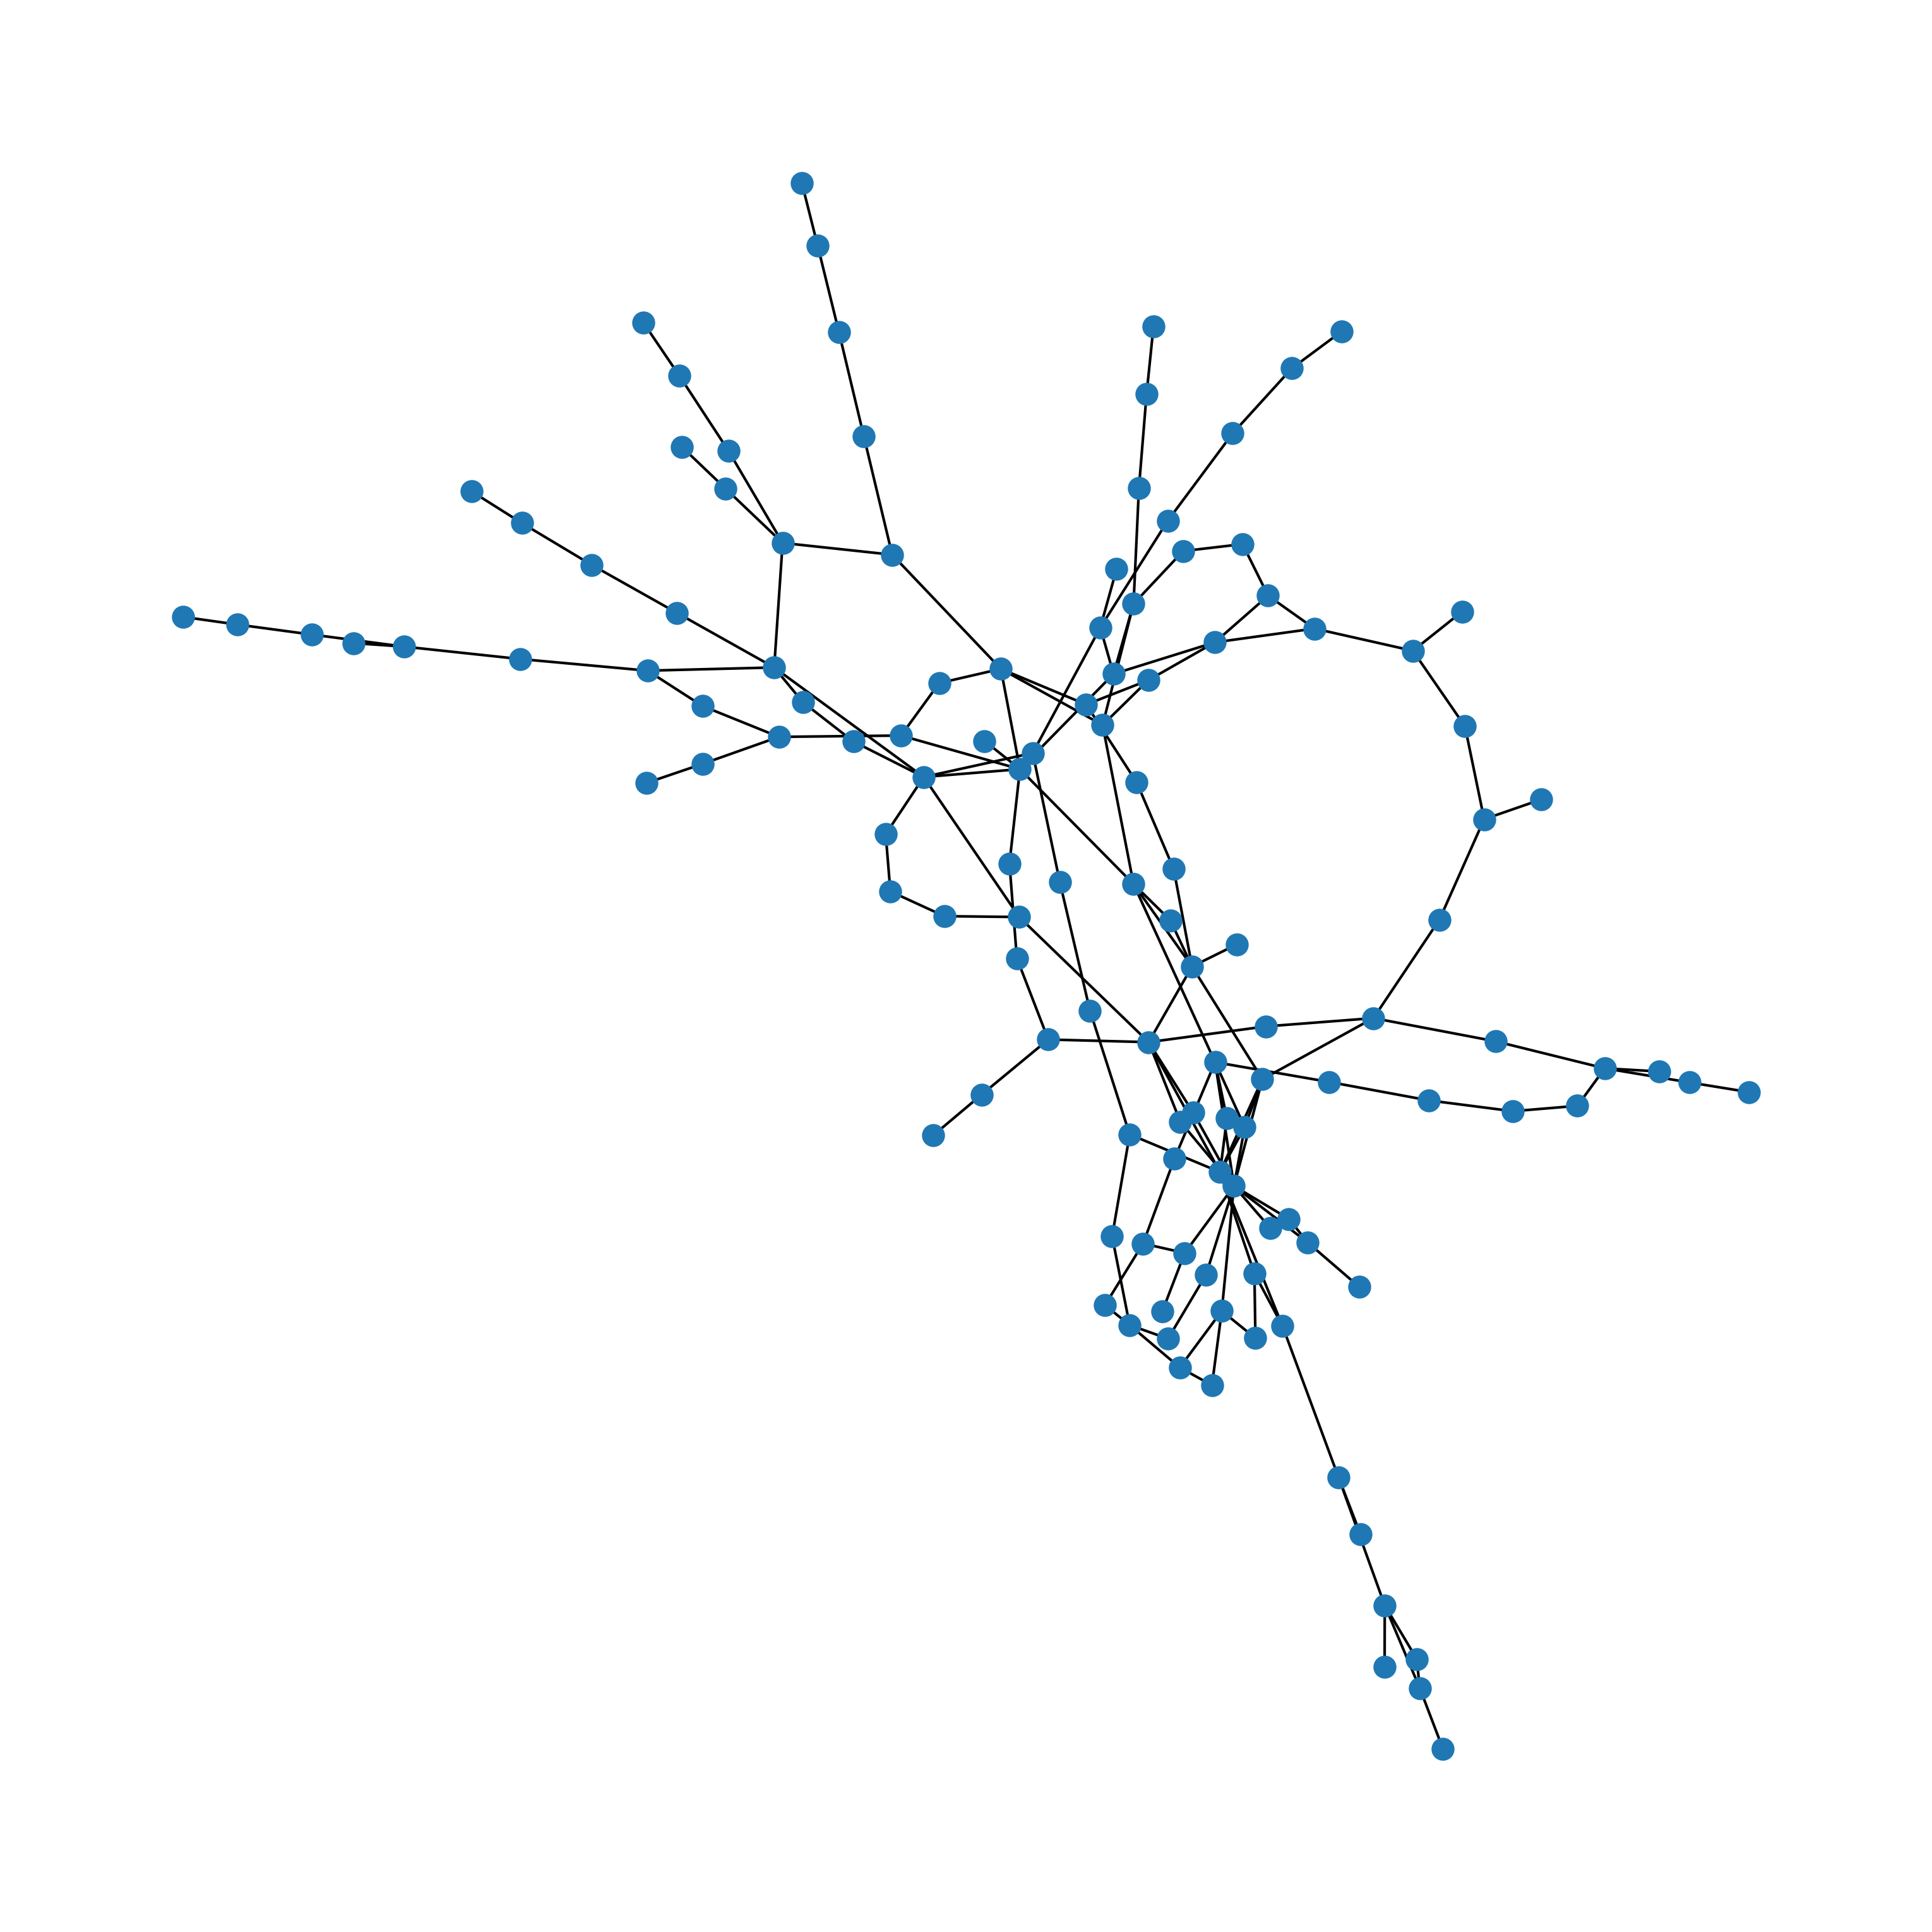

In [2]:
GN=nx.read_adjlist(expanduser("~/Documents/Miktek Files/Betz Inaccesiblity Paper/New York Accessible Network/New_York_Accessible_Network.csv"),delimiter=',')

N = len(GN.nodes)
M = len(GN.edges)

print(nx.diameter(GN))
        
pos=nx.spring_layout(GN,k=1, iterations=1000)
plt.figure(5,figsize=(10,10),dpi=300) 
nx.draw(GN, pos,node_size=60,font_size=8)
plt.savefig('NYACCGraph.png', bbox_inches='tight', dpi=300)

In [3]:
Degn = [val for (node, val) in GN.degree()]

In [4]:
Ben = nx.betweenness_centrality(GN)
Benarr=np.array(list(Ben.values()))

print("Top 10 Betweenness Centrality Nodes")
sorted(Ben.items(), reverse= True, key=lambda x: x[1])[:10]

Top 10 Betweenness Centrality Nodes


[('Grand Central - 42nd St', 0.2850817379141533),
 ('Times Sq - 42nd St', 0.27610896403185914),
 ('Herald Sq - 34th St', 0.25573172893196505),
 ('125th St (4)', 0.2316198968441297),
 ('Fulton St', 0.22073929654574817),
 ('Union Sq - 14th St', 0.19487538534548782),
 ("Atlantic Av - Barclay's Center", 0.18540736625905782),
 ('Jay St - MetroTech', 0.1804339837974771),
 ('Brooklyn Bridge - City Hall', 0.16071272463876704),
 ('Marcy Ave', 0.13621273712737128)]

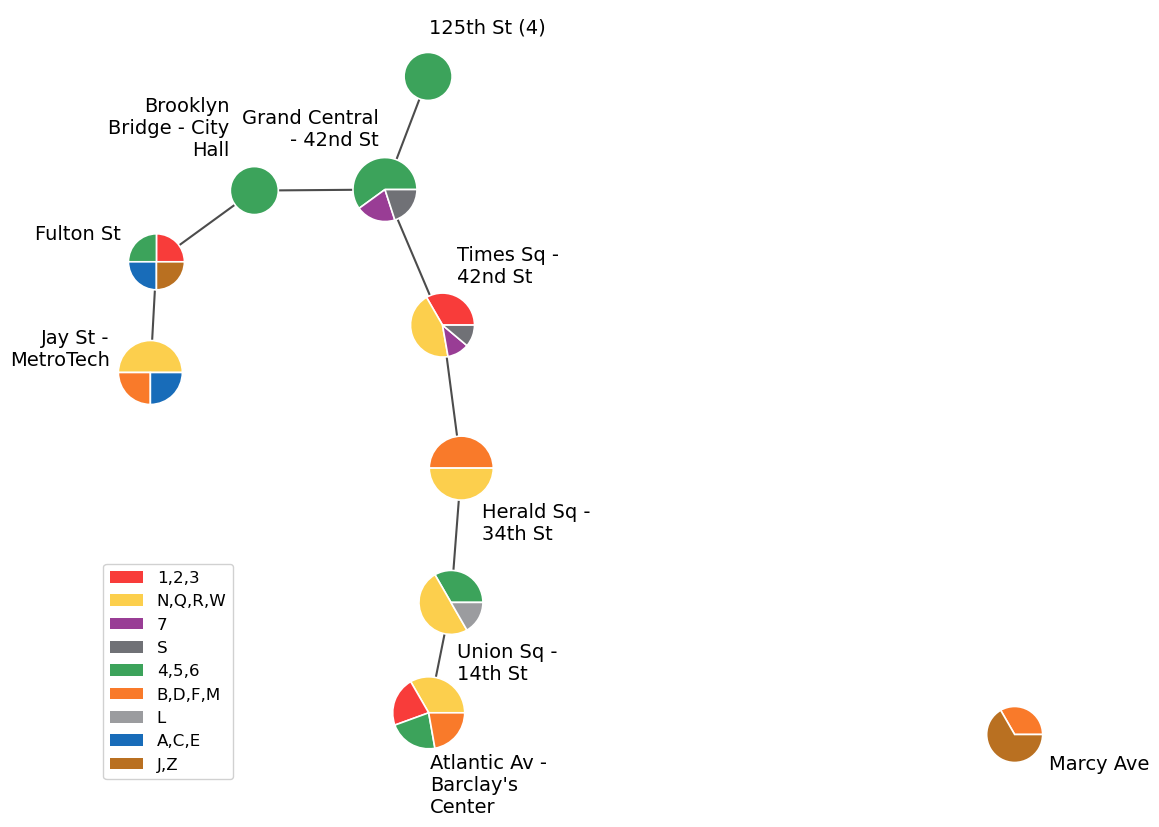

In [5]:
#Top Ten Betweenness Subgraph
HNB = GN.subgraph([node for node, _ in sorted(Ben.items(), key=lambda x: x[1], reverse=True)[:10]])
posb = nx.spring_layout(HNB, seed=42)
HNB = nx.relabel_nodes(HNB, {n: n.strip('\ufeff').strip() for n in HNB.nodes()})

node_configb = {
    'Times Sq - 42nd St': {"slices": [3, 4, 1, 1], "colors": ['#f83c3a','#fccf4d','#993d95','#707176'], "size": 0.08, "legend": ["1,2,3", "N,Q,R,W","7", "S"]},
    'Grand Central - 42nd St': {"slices": [3,1,1], "colors": ['#3ca35b','#993d95','#707176'], "size": 0.08, "legend": ["4,5,6", "7", "S"]},
    'Herald Sq - 34th St': {"slices": [1,1], "colors": ['#f97a2a','#fccf4d'], "size": 0.08,"legend": ["B,D,F,M", "N,Q,R,W"]},
    '125th St (4)': {"slices": [1], "colors": ['#3ca35b'], "size": 0.06,"legend": ["4,5,6"]},
    'Union Sq - 14th St': {"slices": [2,3,1], "colors": ['#3ca35b','#fccf4d','#9b9c9f'], "size": 0.08,"legend": ["4,5,6","N,Q,R,W", "L"]},
    "Atlantic Av - Barclay's Center": {"slices": [3,2,2,2], "colors": ['#fccf4d','#f83c3a','#3ca35b','#f97a2a'], "size": 0.09, "legend": ["N,Q,R,W","1,2,3","4,5,6","B,D,F,M"]},
    'Fulton St': {"slices": [1,1,1,1],"colors": ['#f83c3a','#3ca35b', '#186cb9','#b97021'], "size": 0.07,"legend": ["1,2,3", "4,5,6","A,C,E","J,Z"]},
    'Marcy Ave': {"slices": [1,2], "colors": ['#f97a2a',"#b97021"], "size": 0.07,"legend": ["B,D,F,M","J,Z"]},
    'Jay St - MetroTech': {"slices": [2,1,1], "colors": ['#fccf4d','#f97a2a','#186cb9'], "size": 0.08,"legend": ["N,Q,R,W","B,D,F,M","A,C,E"]},
    'Brooklyn Bridge - City Hall': {"slices": [1], "colors": ['#3ca35b'], "size": 0.06,"legend": ["4,5,6"]}
}

#1,2,3 '#f83c3a'
#4,5,6 '#3ca35b'
#7 '#993d95'
#A '#186cb9'
#B '#f97a2a'
#D '#f97a2a'
#E '#186cb9'
#F '#f97a2a'
#G '#7dc551'
#L '#9b9c9f'
#J '#b97021'
#M '#f97a2a'
#N,Q,R '#fccf4d'
#S '#707176'

fig, ax = plt.subplots(figsize=(14, 10))
ax.set_aspect("equal")
ax.axis("off")

nx.draw_networkx_edges(HNB, posb, ax=ax, edge_color="#000000", width=1.5, alpha=0.7)

# Force layout to initialise before transforms are used
fig.canvas.draw()

for node, (x, y) in posb.items():
    cfg  = node_configb[node]
    size = cfg["size"]

    x_fig, y_fig = ax.transData.transform((x, y))
    x_fig, y_fig = fig.transFigure.inverted().transform((x_fig, y_fig))

    pie_ax = fig.add_axes([x_fig - size / 2, y_fig - size / 2, size, size])
    pie_ax.pie(cfg["slices"], colors=cfg["colors"],
               wedgeprops=dict(linewidth=1.2, edgecolor="white"))
    pie_ax.set_aspect("equal")

cx = np.mean([x for x, y in posb.values()])
cy = np.mean([y for x, y in posb.values()])

for node, (x, y) in posb.items():
    cfg = node_configb[node]
    angle = np.arctan2(y - cy, x - cx)
    offset = cfg["size"] * 0.1 + 0.06

    lx = x + np.cos(angle) * offset
    ly = y + np.sin(angle) * offset

    ha = "left" if np.cos(angle) > 0 else "right"
    va = "bottom" if np.sin(angle) > 0 else "top"

    label = textwrap.fill(node, width=14)   # wrap at 14 characters

    ax.text(lx, ly, label, ha=ha, va=va,
            fontsize=14, fontweight="medium", color="#000000", zorder=10,
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7))

seen = {}
for cfg in node_configb.values():
    for color, label in zip(cfg["colors"], cfg["legend"]):
        if label not in seen:
            seen[label] = color

handles = [Patch(facecolor=color, label=label) for label, color in seen.items()]

ax.legend(
    handles=handles,
    loc="lower left",
    fontsize=12,
    bbox_to_anchor=(-.06, -.01),
    title_fontsize=9,
    framealpha=0.9,
    edgecolor="#cccccc"
)

plt.show()

In [6]:
Cen = nx.closeness_centrality(GN)
Cenarr=np.array(list(Cen.values()))

print("Top 10 Closeness Centrality Nodes")
sorted(Cen.items(), reverse= True, key=lambda x: x[1])[:10]

Top 10 Closeness Centrality Nodes


[('Times Sq - 42nd St', 0.24652087475149106),
 ('Herald Sq - 34th St', 0.24603174603174602),
 ('Grand Central - 42nd St', 0.23892100192678228),
 ('Fulton St', 0.23754789272030652),
 ('Brooklyn Bridge - City Hall', 0.23177570093457944),
 ('W 4th St - Washington Sq', 0.23177570093457944),
 ('Union Sq - 14th St', 0.22962962962962963),
 ('Broadway - Lafayette St', 0.22142857142857142),
 ('47th-50th Sts - Rockefeller Ctr', 0.21946902654867256),
 ('Jay St - MetroTech', 0.2171628721541156)]

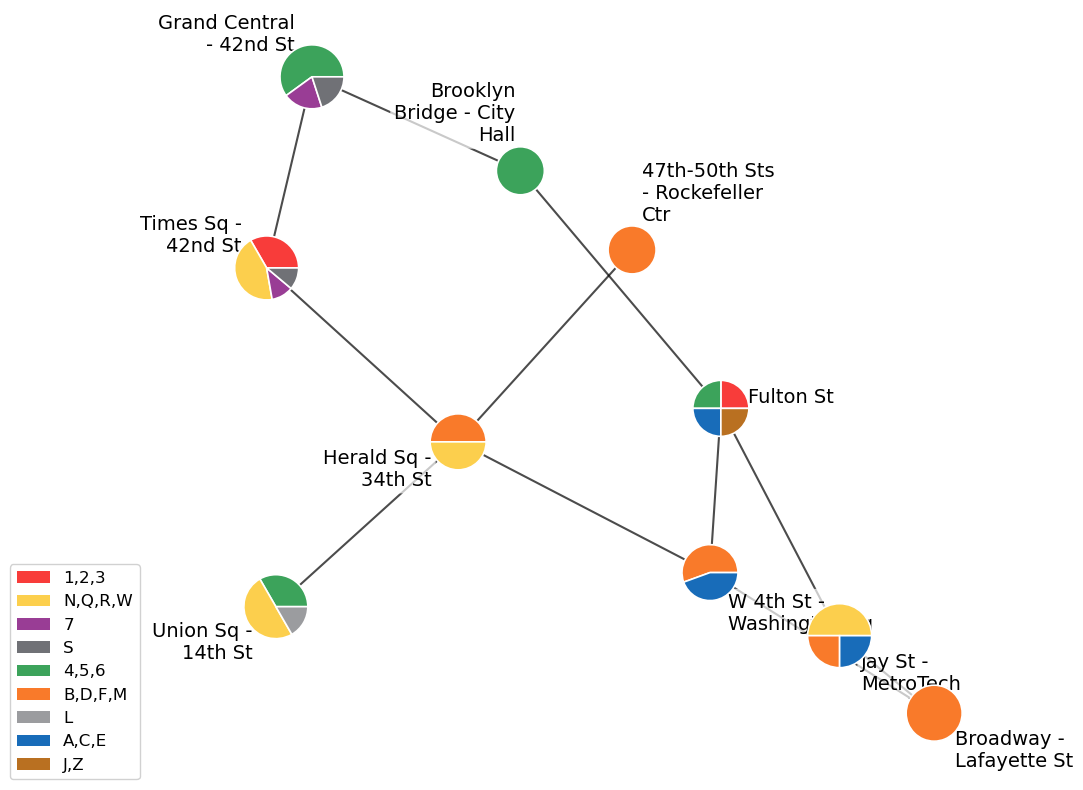

In [7]:
#Top Ten Closeness Subgraph
HNC=GN.subgraph([node for node, _ in sorted(Cen.items(), key=lambda x: x[1], reverse=True)[:10]])
posc = nx.spring_layout(HNC, seed=49)
HNC = nx.relabel_nodes(HNC, {n: n.strip('\ufeff').strip() for n in HNC.nodes()})

node_configc = {
    'Times Sq - 42nd St': {"slices": [3, 4, 1, 1], "colors": ['#f83c3a','#fccf4d','#993d95','#707176'], "size": 0.08, "legend": ["1,2,3", "N,Q,R,W","7", "S"]},
    'Grand Central - 42nd St': {"slices": [3,1,1], "colors": ['#3ca35b','#993d95','#707176'], "size": 0.08, "legend": ["4,5,6", "7", "S"]},
    'Herald Sq - 34th St': {"slices": [1,1], "colors": ['#f97a2a','#fccf4d'], "size": 0.07,"legend": ["B,D,F,M", "N,Q,R,W"]},
    'Broadway - Lafayette St': {"slices": [1],"colors": ['#f97a2a'], "size": 0.07,"legend": ["B,D,F,M"]},
    'Union Sq - 14th St': {"slices": [2,3,1], "colors": ['#3ca35b','#fccf4d','#9b9c9f'], "size": 0.08,"legend": ["4,5,6","N,Q,R,W", "L"]},
    'W 4th St - Washington Sq': {"slices": [5,4],"colors": ['#f97a2a','#186cb9'], "size": 0.07, "legend": ["B,D,F,M", "A,C,E"]},
    'Fulton St': {"slices": [1,1,1,1],"colors": ['#f83c3a','#3ca35b', '#186cb9','#b97021'], "size": 0.07,"legend": ["1,2,3", "4,5,6","A,C,E","J,Z"]},
    '47th-50th Sts - Rockefeller Ctr': {"slices": [1], "colors": ['#f97a2a'], "size": 0.06,"legend": ["B,D,F,M"]},
    'Jay St - MetroTech': {"slices": [2,1,1], "colors": ['#fccf4d','#f97a2a','#186cb9'], "size": 0.08,"legend": ["N,Q,R,W","B,D,F,M","A,C,E"]},
    'Brooklyn Bridge - City Hall': {"slices": [1], "colors": ['#3ca35b'], "size": 0.06,"legend": ["4,5,6"]}
}


#1,2,3 '#f83c3a'
#4,5,6 '#3ca35b'
#7 '#993d95'
#A '#186cb9'
#B '#f97a2a'
#D '#f97a2a'
#E '#186cb9'
#F '#f97a2a'
#G '#7dc551'
#L '#9b9c9f'
#J '#b97021'
#M '#f97a2a'
#N,Q,R '#fccf4d'
#S '#707176'

fig, ax = plt.subplots(figsize=(14, 10))
ax.set_aspect("equal")
ax.axis("off")

nx.draw_networkx_edges(HNC, posc, ax=ax, edge_color="#000000", width=1.5, alpha=0.7)

# Force layout to initialise before transforms are used
fig.canvas.draw()

for node, (x, y) in posc.items():
    cfg  = node_configc[node]
    size = cfg["size"]

    x_fig, y_fig = ax.transData.transform((x, y))
    x_fig, y_fig = fig.transFigure.inverted().transform((x_fig, y_fig))

    pie_ax = fig.add_axes([x_fig - size / 2, y_fig - size / 2, size, size])
    pie_ax.pie(cfg["slices"], colors=cfg["colors"],
               wedgeprops=dict(linewidth=1.2, edgecolor="white"))
    pie_ax.set_aspect("equal")

cx = np.mean([x for x, y in posc.values()])
cy = np.mean([y for x, y in posc.values()])

for node, (x, y) in posc.items():
    cfg = node_configc[node]
    angle = np.arctan2(y - cy, x - cx)
    offset = cfg["size"] * 0.2 + 0.06

    lx = x + np.cos(angle) * offset
    ly = y + np.sin(angle) * offset

    ha = "left" if np.cos(angle) > 0 else "right"
    va = "bottom" if np.sin(angle) > 0 else "top"

    label = textwrap.fill(node, width=14)   # wrap at 14 characters

    ax.text(lx, ly, label, ha=ha, va=va,
            fontsize=14, fontweight="medium", color="#000000", zorder=10,
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7))

seen = {}
for cfg in node_configc.values():
    for color, label in zip(cfg["colors"], cfg["legend"]):
        if label not in seen:
            seen[label] = color

handles = [Patch(facecolor=color, label=label) for label, color in seen.items()]

ax.legend(
    handles=handles,
    loc="lower right",
    fontsize=12,
    bbox_to_anchor=(-.06, -.01),
    title_fontsize=9,
    framealpha=0.9,
    edgecolor="#cccccc"
)

plt.show()

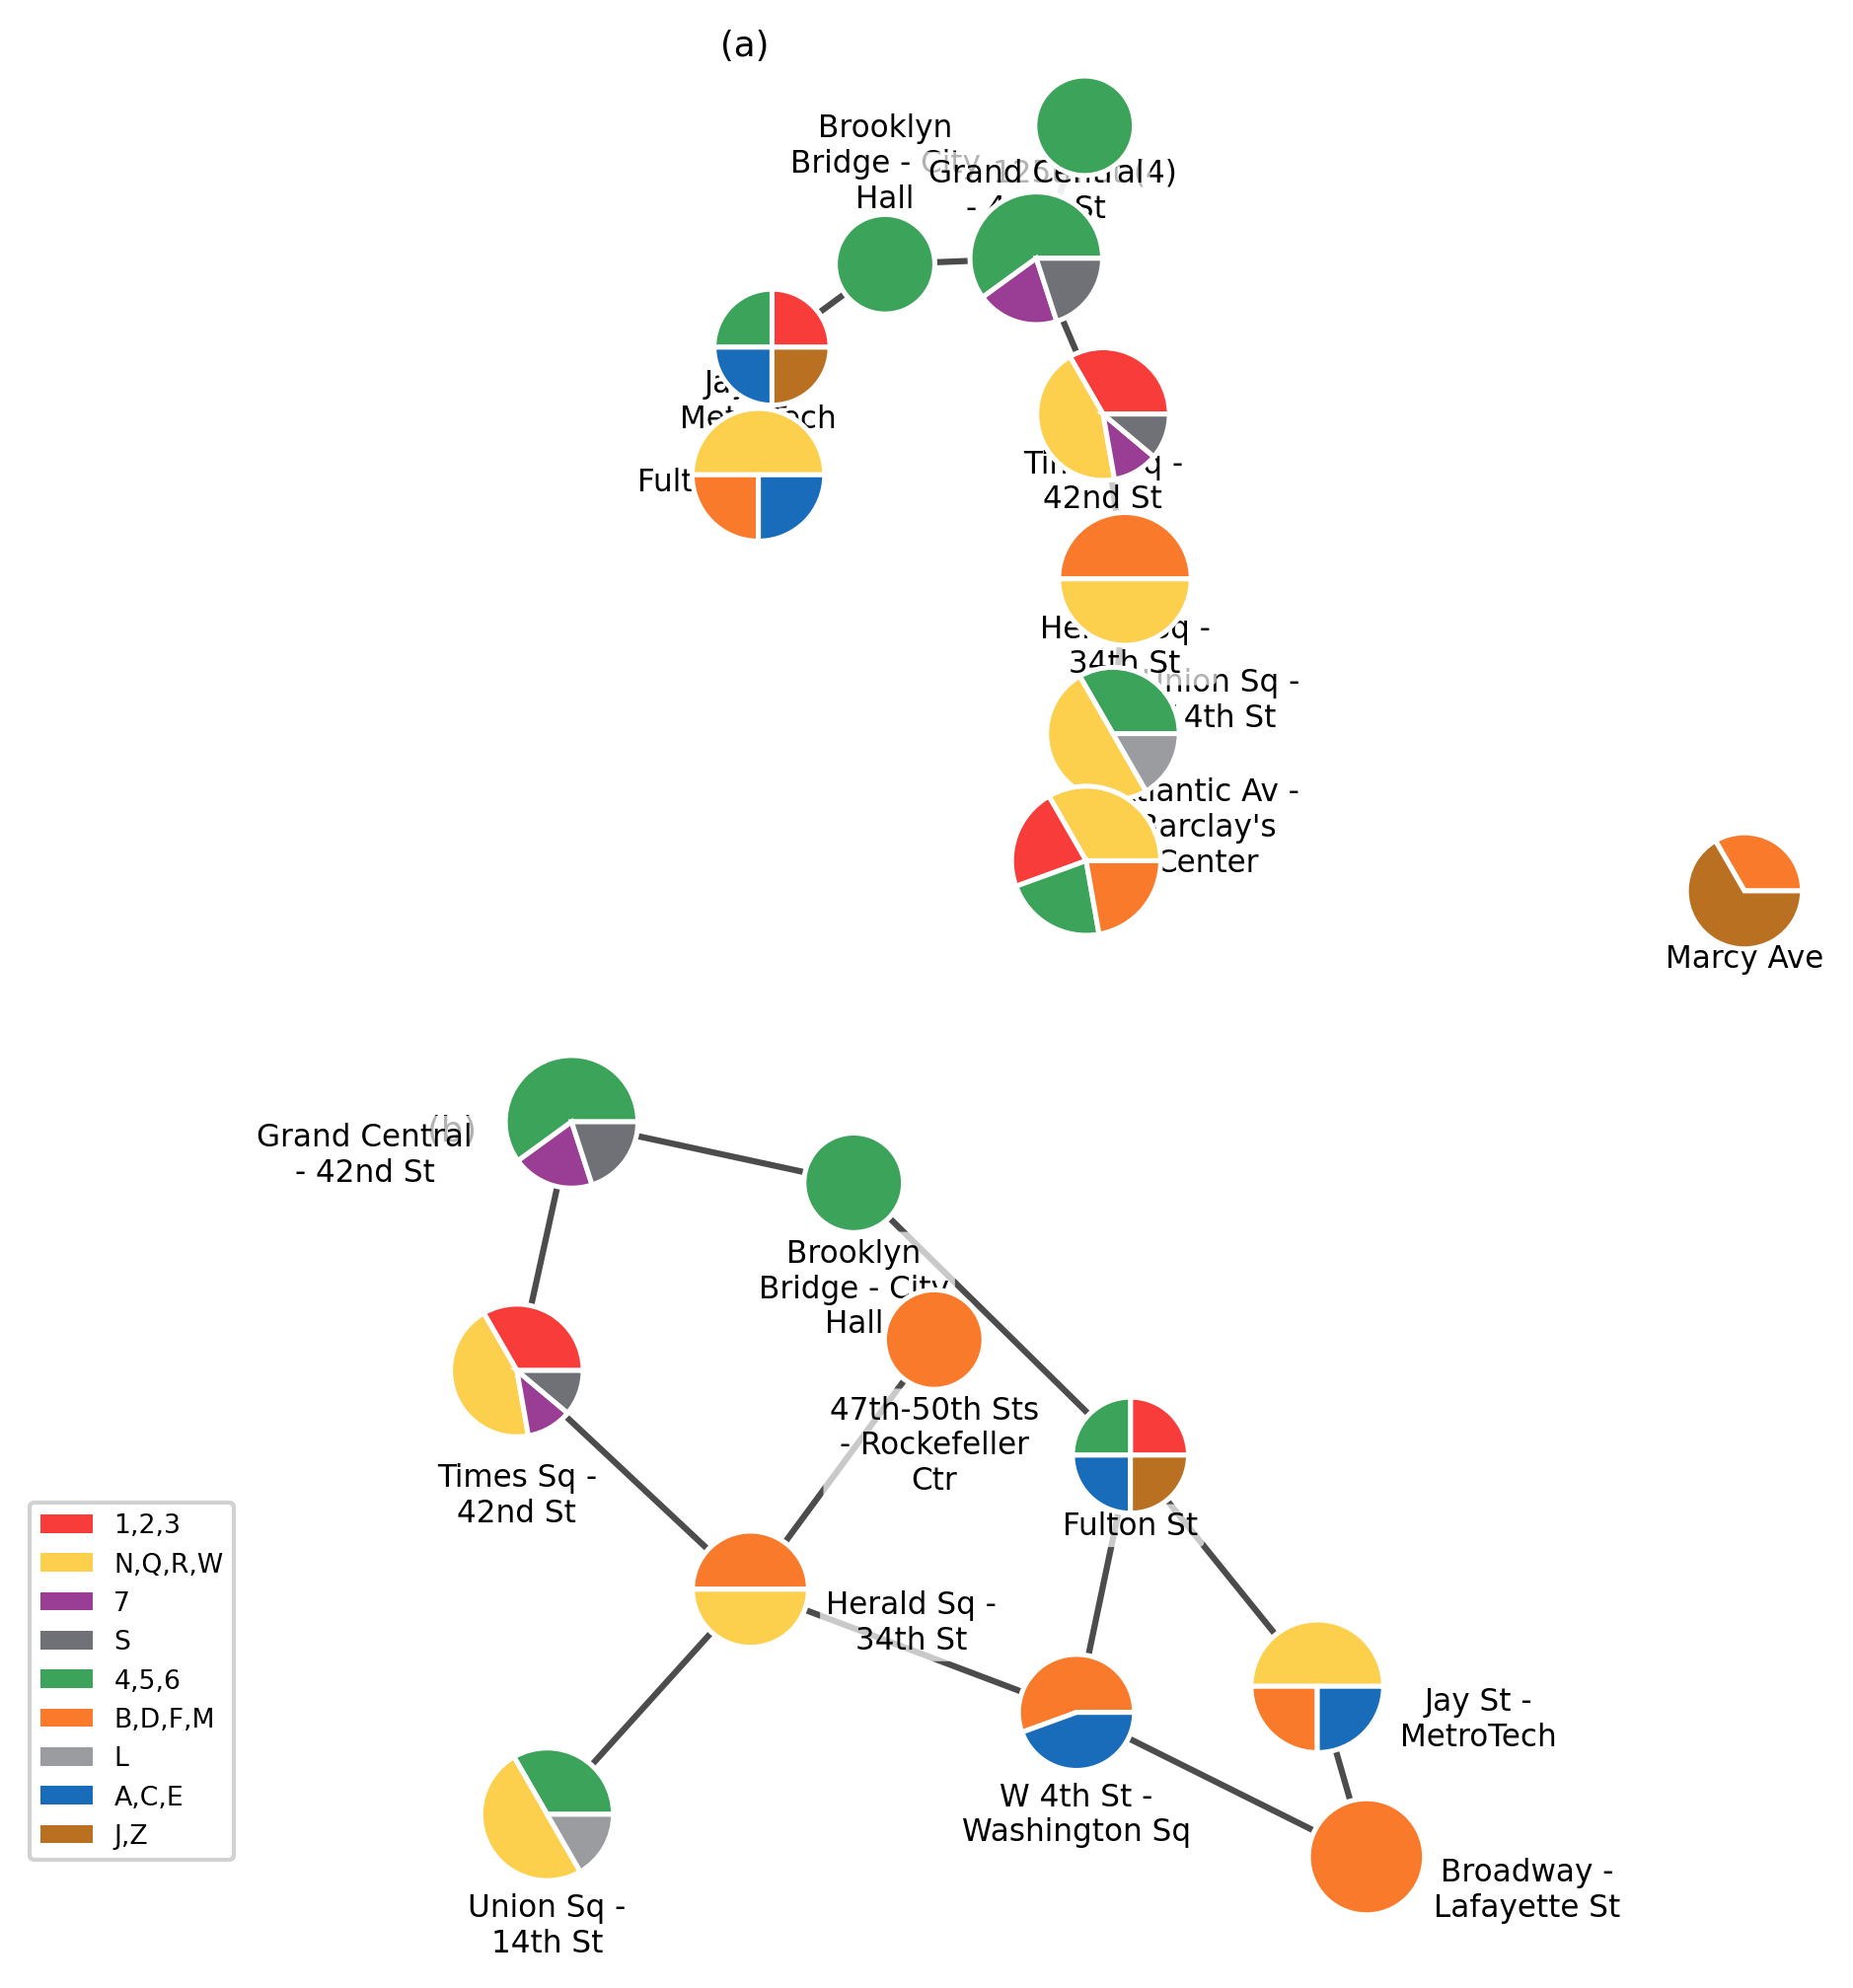

In [8]:
fig = plt.figure(figsize=(8,7), dpi=300)
scale = fig.get_size_inches()[0] / 15
fig.subplots_adjust(left=0.06, right=0.80, top=0.97, bottom=0.06, hspace=0.12)
posb = nx.spring_layout(HNB, seed=42, k=.32)
posc = nx.spring_layout(HNC, seed=49, k=.32)

# ── (a) Betweenness ──────────────────────────────────────────────────────────
ax1 = fig.add_subplot(2, 1, 1)
ax1.set_aspect("equal")
ax1.axis("off")
ax1.set_title("(a)", fontsize=16*scale, fontweight="medium", y=.9, pad=20, loc="left")
nx.draw_networkx_edges(HNB, posb, ax=ax1, edge_color="#000000", width=1.5, alpha=0.7)

ax2 = fig.add_subplot(2, 1, 2)
ax2.set_aspect("equal")
ax2.axis("off")
ax2.set_title("(b)", fontsize=16*scale, fontweight="medium", y=.8, pad=20, loc="left")

nx.draw_networkx_edges(HNC, posc, ax=ax2, edge_color="#000000", width=1.5, alpha=0.7)

fig.canvas.draw()

for node, (x, y) in posb.items():
    cfg = node_configb[node]
    size = cfg["size"]
    x_fig, y_fig = ax1.transData.transform((x, y))
    x_fig, y_fig = fig.transFigure.inverted().transform((x_fig, y_fig))
    pie_ax = fig.add_axes([x_fig - size/2, y_fig - size/2, size, size])
    pie_ax.pie(cfg["slices"], colors=cfg["colors"], wedgeprops=dict(linewidth=1.2, edgecolor="white"))
    pie_ax.set_aspect("equal")

label_offsetsb = {
    'Times Sq - 42nd St':                (0, -0.1),
    'Grand Central - 42nd St':     (0, 0.1),
    'Herald Sq - 34th St': (0, -.1),
    '125th St (4)':             (0, -0.07),
    'Union Sq - 14th St':              (.16, .05),
    "Atlantic Av - Barclay's Center":              (.18,.05),
    'Fulton St':          (-.1,-.2),
    'Marcy Ave':                 (0, -0.1),
    'Jay St - MetroTech':               (0, .11),
    'Brooklyn Bridge - City Hall':              (0, 0.15),
}

cx_b = np.mean([x for x, y in posb.values()])
cy_b = np.mean([y for x, y in posb.values()])

texts = []
for node, (x, y) in posb.items():
    cfg = node_configb[node]
    angle = np.arctan2(y - cy_b, x - cx_b)
    offset = cfg["size"] *.01 + 0.01
    dx, dy = label_offsetsb.get(node, (0, -.5))
    lx = x + dx
    ly = y + dy
    ax1.text(lx, ly, textwrap.fill(node, 14),
                 ha='center', va='center',
                 fontsize=14*scale, fontweight="medium",
                 bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7))

seen = {}
for cfg in node_configb.values():
    for color, label in zip(cfg["colors"], cfg["legend"]):
        if label not in seen:
            seen[label] = color
    
# ── (b) Closeness ────────────────────────────────────────────────────────────
for node, (x, y) in posc.items():
    cfg = node_configc[node]
    size = cfg["size"]
    x_fig, y_fig = ax2.transData.transform((x, y))
    x_fig, y_fig = fig.transFigure.inverted().transform((x_fig, y_fig))
    pie_ax = fig.add_axes([x_fig - size/2, y_fig - size/2, size, size])
    pie_ax.pie(cfg["slices"], colors=cfg["colors"], wedgeprops=dict(linewidth=1.2, edgecolor="white"))
    pie_ax.set_aspect("equal")

cx_c = np.mean([x for x, y in posc.values()])
cy_c = np.mean([y for x, y in posc.values()])

label_offsetsc = {
    'Times Sq - 42nd St':            (0, -0.2),
    'Grand Central - 42nd St':              (-.45, 0),
    'Herald Sq - 34th St':               (.35, 0),
    'Broadway - Lafayette St':                (.35, 0),
    'Union Sq - 14th St': (0, -0.17),
    'W 4th St - Washington Sq':              (0, -0.15),
    'Fulton St':               (0, -0.12),
    '47th-50th Sts - Rockefeller Ctr':     (0, -0.12),
    'Jay St - MetroTech':         (.35,0),
    'Brooklyn Bridge - City Hall':         (0, -0.12),
}

for node, (x, y) in posc.items():
    cfg = node_configc[node]
    angle = np.arctan2(y - cy_c, x - cx_c)
    offset = cfg["size"] *.01 + 0.01
    dx, dy = label_offsetsc.get(node, (0, -(cfg["size"] + 0.1)))
    lx = x + dx
    ly = y + dy
    ax2.text(lx, ly, textwrap.fill(node, width=14), ha='center', va='top',
             fontsize=14*scale, fontweight="medium", color="#000000", zorder=10,
             bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7))

seen = {}
for cfg in node_configc.values():
    for color, label in zip(cfg["colors"], cfg["legend"]):
        if label not in seen:
            seen[label] = color

ax2.legend(handles=[Patch(facecolor=c, label=l) for l, c in seen.items()],
           loc="upper left", fontsize=12*scale, bbox_to_anchor=(-.4, .5), framealpha=0.9, edgecolor="#cccccc")

plt.savefig("Fig7.TIFF")
plt.show()

# Total Network for Comparison

41


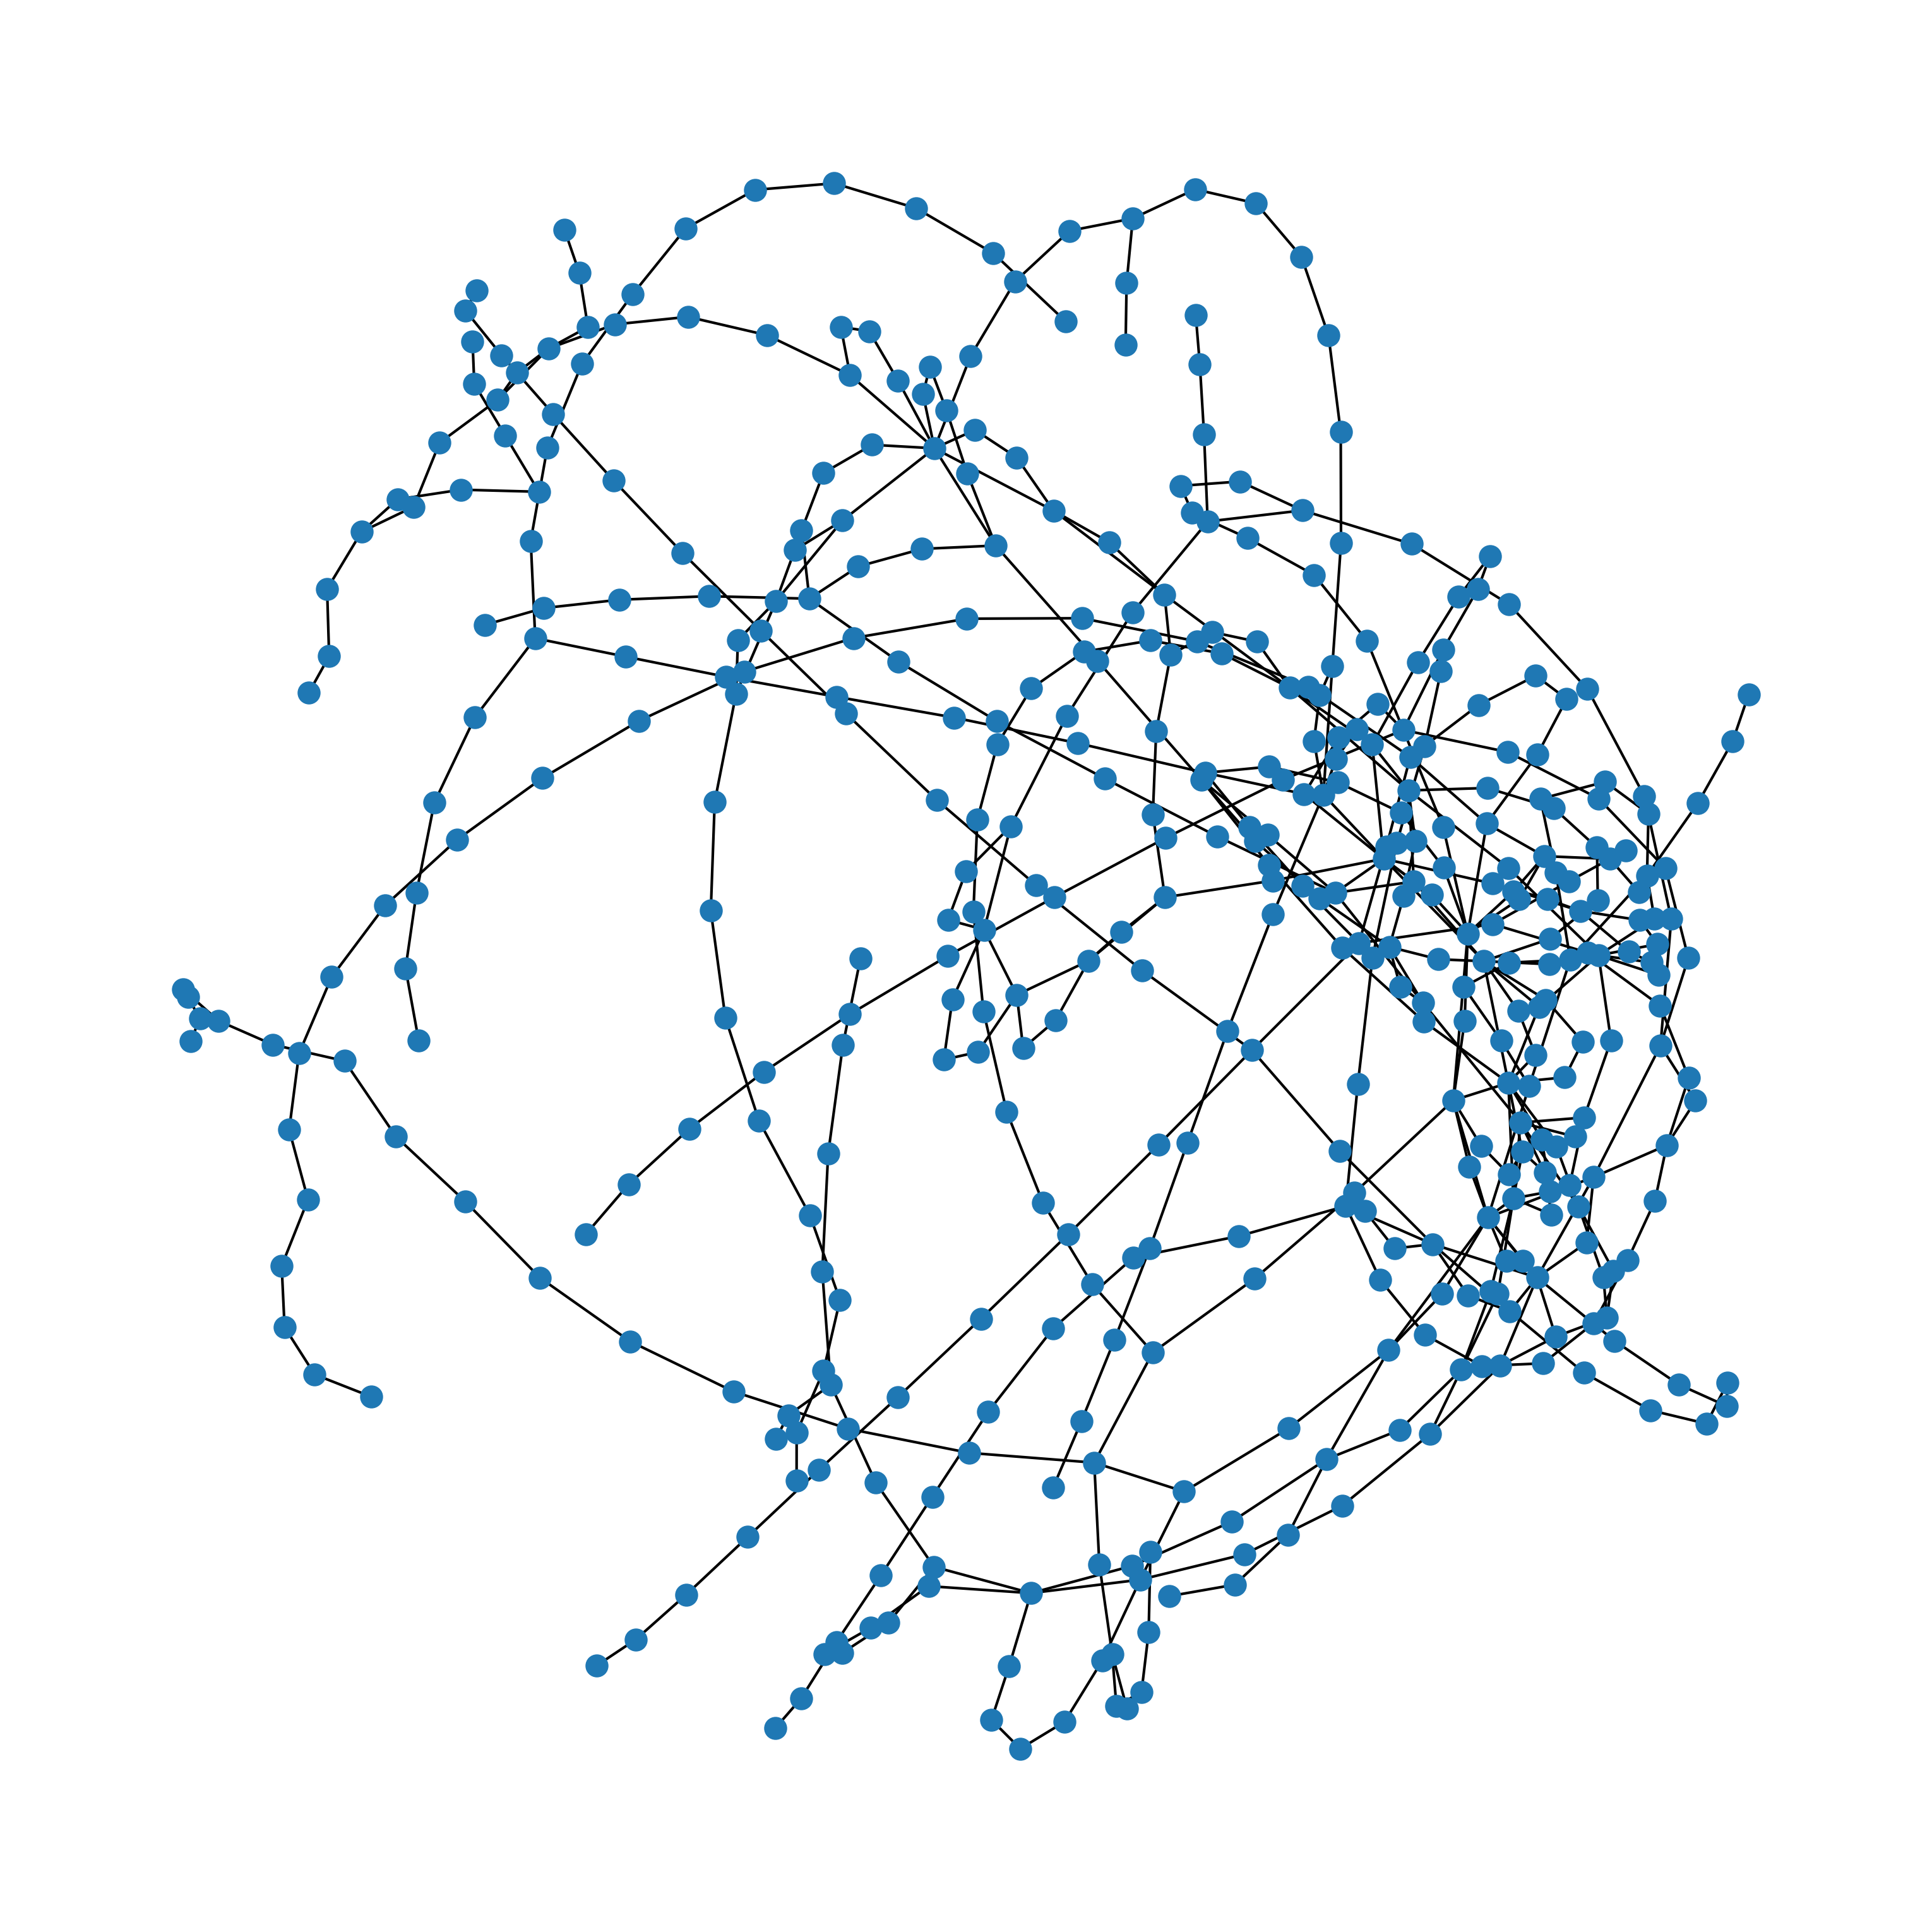

In [9]:
GTot=nx.read_adjlist(expanduser("~/Documents/Miktek Files/Betz Inaccesiblity Paper/New-York-Metro-Master-Dataset/New_York_Metro_Network.csv"),delimiter=',')
NT = len(GTot.nodes)
MT = len(GTot.edges)     

print(nx.diameter(GTot))

pos=nx.spring_layout(GTot,k=1, iterations=1000)
plt.figure(5,figsize=(10,10),dpi=300) 
nx.draw(GTot, pos,node_size=60,font_size=8)
plt.savefig('NYTOTGraph.png', bbox_inches='tight', dpi=300)

In [10]:
Degnt = [val for (node, val) in GTot.degree()]

In [11]:
Bent = nx.betweenness_centrality(GTot)
Bentarr=np.array(list(Bent.values()))

print("Top 10 Betweenness Centrality Nodes")
sorted(Bent.items(), reverse= True, key=lambda x: x[1])[:10]

Top 10 Betweenness Centrality Nodes


[("Atlantic Av - Barclay's Center", 0.3586797067427365),
 ('Times Sq - 42nd St', 0.32532868113126234),
 ('Grand Central - 42nd St', 0.24792693726377157),
 ('59th St', 0.22432599595808173),
 ('14th St - Union Sq', 0.20074182771149154),
 ('Broadway Junction', 0.19544131930207223),
 ('Hoyt Schermerhorn', 0.17498497874639252),
 ('59th St - Columbus Circle', 0.16479135571919296),
 ('Canal St (6)', 0.16348163476716776),
 ('Nostrand Ave (A)', 0.1599143906073156)]

In [12]:
Cent = nx.closeness_centrality(GTot)
Centarr=np.array(list(Cent.values()))

print("Top 10 Closeness Centrality Nodes")
sorted(Cent.items(), reverse= True, key=lambda x: x[1])[:10]

Top 10 Closeness Centrality Nodes


[('59th St', 0.13197815533980584),
 ('Grand Central - 42nd St', 0.13122171945701358),
 ("Atlantic Av - Barclay's Center", 0.13059141398979285),
 ('14th St - Union Sq', 0.13043478260869565),
 ('36th St (N)', 0.12919512919512918),
 ('Times Sq - 42nd St', 0.12797881729920565),
 ('Canal St (6)', 0.12790355777712437),
 ('Herald Sq - 34th St', 0.12678519382104342),
 ('DeKalb Ave', 0.12471330275229357),
 ('Grand St', 0.12302036199095022)]

# Comparison Accessible versus Total Centrality

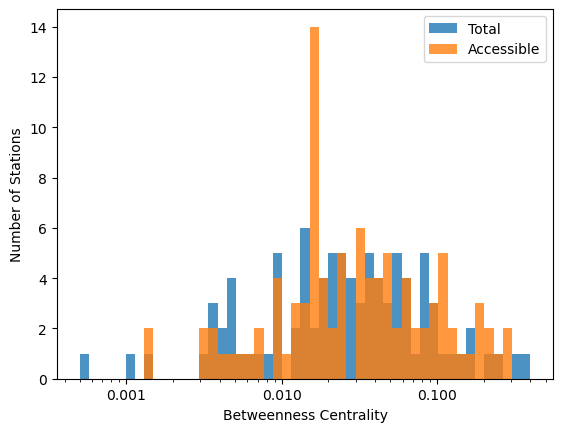

In [13]:
GTot = nx.relabel_nodes(GTot, {n: n.strip('\ufeff').strip() for n in GTot.nodes()})
GN = nx.relabel_nodes(GN, {n: n.strip('\ufeff').strip() for n in GN.nodes()})

bel_full = nx.betweenness_centrality(GTot)

BBB = np.array([bel_full.get(node, 0) for node in GN.nodes()])

MIN1, MAX1 = .0005, .4

fig, ax = plt.subplots()
plt.hist(BBB, bins = 10 ** np.linspace(np.log10(MIN1), np.log10(MAX1), 50),alpha=0.8)
plt.hist(Benarr, bins = 10 ** np.linspace(np.log10(MIN1), np.log10(MAX1), 50),alpha=.8)
pl.gca().set_xscale("log")
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
plt.ticklabel_format(axis='x', style='plain')
plt.xlabel("Betweenness Centrality")
plt.ylabel("Number of Stations")
plt.legend(["Total", "Accessible"], fontsize=10)
pl.show()

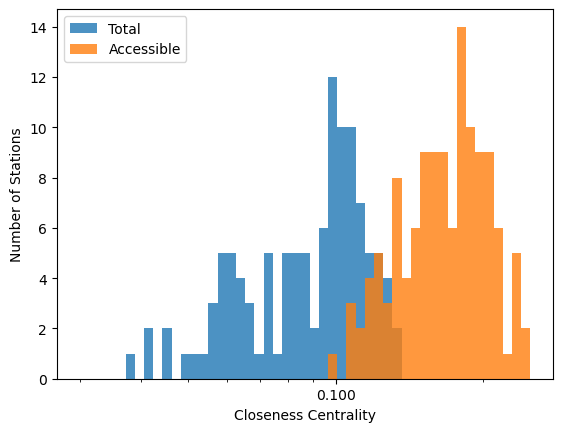

In [14]:
cel_full = nx.closeness_centrality(GTot)

CCC = np.array([cel_full.get(node, 0) for node in GN.nodes()])

MIN2, MAX2 = .03, .25

fig, ax = plt.subplots()
plt.hist(CCC, bins = 10 ** np.linspace(np.log10(MIN2), np.log10(MAX2), 50),alpha=0.8)
plt.hist(Cenarr, bins = 10 ** np.linspace(np.log10(MIN2), np.log10(MAX2), 50),alpha=.8)
pl.gca().set_xscale("log")
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
plt.ticklabel_format(axis='x', style='plain')
plt.xlabel("Closeness Centrality")
plt.ylabel("Number of Stations")
plt.legend(["Total", "Accessible"], fontsize=10)
pl.show()

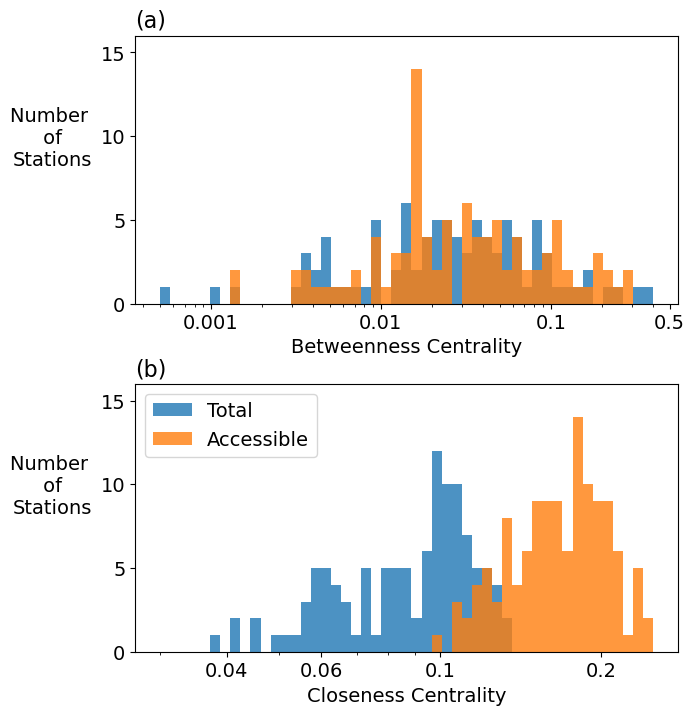

In [15]:
fig, ax = plt.subplots(2,1,figsize=(7,8))

ax[0].set_title('(a)',loc='left', fontsize=16)
ax[0].hist(BBB, bins = 10 ** np.linspace(np.log10(MIN1), np.log10(MAX1), 50),alpha=0.8)
ax[0].hist(Benarr, bins = 10 ** np.linspace(np.log10(MIN1), np.log10(MAX1), 50),alpha=.8)
ax[0].xaxis.set_major_formatter(ticker.ScalarFormatter())
ax[0].tick_params(axis='both', labelsize=14)
ax[0].set_xlabel("Betweenness Centrality", fontsize=14)
ax[0].set_ylabel("Number \n of \nStations", rotation=0, fontsize=14)
ax[0].set_xscale("log")
ax[0].yaxis.labelpad=35
ax[0].set_ylim(0,16)
ax[0].set_xticks([0.001,0.01,0.1,0.5])
ax[0].set_xticklabels(['0.001','0.01','0.1','0.5'])

ax[1].set_title('(b)',loc='left', fontsize=16)
ax[1].hist(CCC, bins = 10 ** np.linspace(np.log10(MIN2), np.log10(MAX2), 50),alpha=0.8)
ax[1].hist(Cenarr, bins = 10 ** np.linspace(np.log10(MIN2), np.log10(MAX2), 50),alpha=.8)
ax[1].xaxis.set_major_formatter(ticker.ScalarFormatter())
ax[1].tick_params(axis='both', labelsize=14)
ax[1].set_xlabel("Closeness Centrality", fontsize=14)
ax[1].set_ylabel("Number \n of \nStations", rotation=0, fontsize=14, labelpad=35)
ax[1].set_ylim(0,16)
ax[1].set_xscale("log")
ax[1].set_xticks([0.04,0.06,0.1,0.2])
ax[1].set_xticklabels(['0.04','0.06','0.1','0.2'])
plt.legend(["Total", "Accessible"], fontsize=14)
plt.subplots_adjust(hspace=0.3)
plt.savefig('Fig8.tiff', bbox_inches='tight', dpi=300)

# Comparison Degree versus Centrality Measures

''

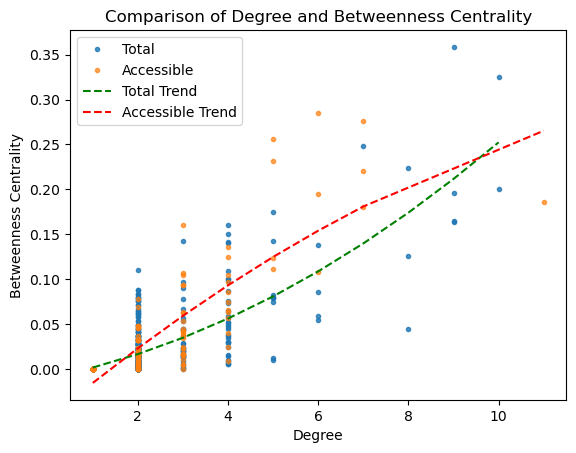

In [16]:
plt.plot(Degnt,Bentarr,'.', alpha=.8)

Degll=np.array(list(Degn))
Deglll=np.array(list(Degnt))
sorted_indicest = np.argsort(Deglll)
sorted_indices = np.argsort(Degll)
xt1_sorted = Deglll[sorted_indicest]
yt1_sorted = Bentarr[sorted_indicest]

zt1 = np.polyfit(xt1_sorted, yt1_sorted,2)
pt1 = np.poly1d(zt1)

plt.plot(Degn,Benarr,'.', alpha=.7)

xa1_sorted = Degll[sorted_indices]
ya1_sorted = Benarr[sorted_indices]

za1 = np.polyfit(xa1_sorted, ya1_sorted,2)
pa1 = np.poly1d(za1)
plt.plot(xt1_sorted, pt1(xt1_sorted), "g--")
plt.plot(xa1_sorted, pa1(xa1_sorted), "r--")

plt.legend(["Total","Accessible","Total Trend", "Accessible Trend"])
plt.xlabel('Degree')
plt.ylabel('Betweenness Centrality')
plt.title('Comparison of Degree and Betweenness Centrality')
;

''

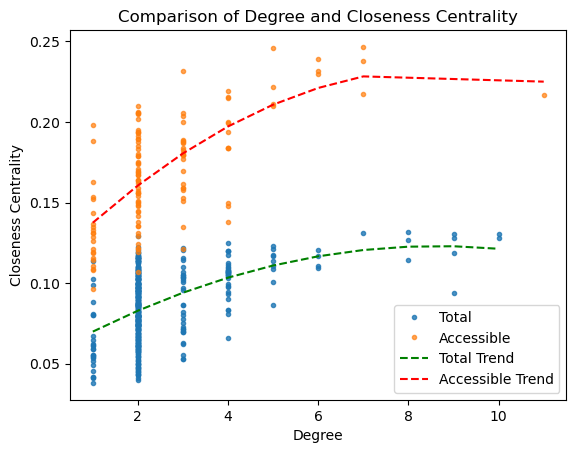

In [17]:
plt.plot(Degnt,Centarr,'.', alpha=0.8)

sorted_indices = np.argsort(Degll)
Deglll=np.array(list(Degnt))
sorted_indicest = np.argsort(Deglll)
xt2_sorted = Deglll[sorted_indicest]
yt2_sorted = Centarr[sorted_indicest]

zt2 = np.polyfit(xt2_sorted, yt2_sorted,2)
pt2 = np.poly1d(zt2)

plt.plot(Degn,Cenarr,'.', alpha=0.7)

xa2_sorted = Degll[sorted_indices]
ya2_sorted = Cenarr[sorted_indices]

za2 = np.polyfit(xa2_sorted, ya2_sorted,2)
pa2 = np.poly1d(za2)
plt.plot(xt2_sorted, pt2(xt2_sorted), "g--")
plt.plot(xa2_sorted, pa2(xa2_sorted), "r--")

plt.legend(["Total","Accessible","Total Trend", "Accessible Trend"])
plt.xlabel('Degree')
plt.ylabel('Closeness Centrality')
plt.title('Comparison of Degree and Closeness Centrality')
;

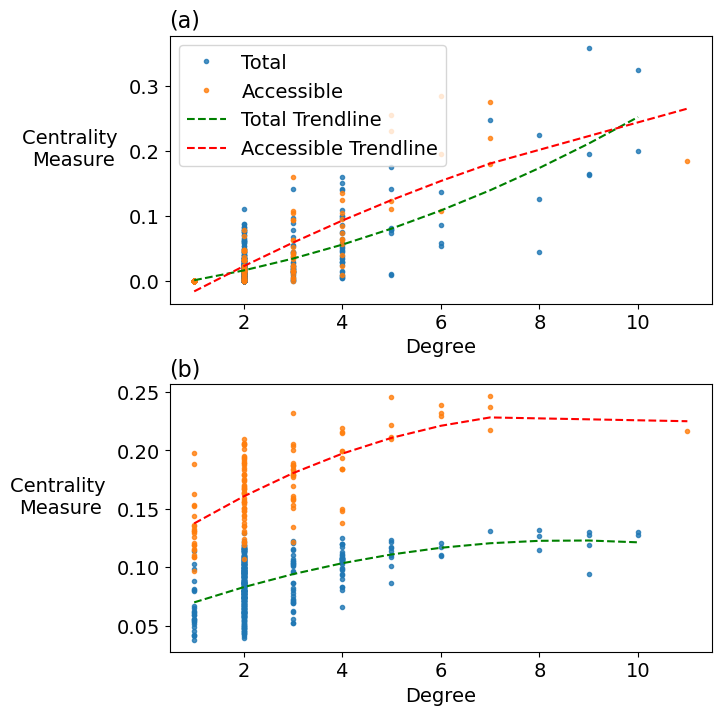

In [18]:
fig, ax = plt.subplots(2,1,figsize=(7,8))

ax[0].set_title('(a)',loc='left', fontsize=16)
ax[0].plot(Degnt,Bentarr,'.', alpha=.8)
ax[0].plot(Degn,Benarr,'.', alpha=.8)
ax[0].plot(xt1_sorted, pt1(xt1_sorted), "g--")
ax[0].plot(xa1_sorted, pa1(xa1_sorted), "r--")
ax[0].xaxis.set_major_formatter(ticker.ScalarFormatter())
ax[0].tick_params(axis='both', labelsize=14)
ax[0].yaxis.labelpad=40
ax[0].set_xlabel("Degree", fontsize=14)
ax[0].set_ylabel("Centrality \nMeasure", rotation=0, fontsize=14)
ax[0].legend(["Total", "Accessible", "Total Trendline", "Accessible Trendline"], fontsize=14)

ax[1].set_title('(b)',loc='left', fontsize=16)
ax[1].plot(Degnt,Centarr,'.', alpha=0.8)
ax[1].plot(Degn,Cenarr,'.', alpha=0.8)
ax[1].plot(xt2_sorted, pt2(xt2_sorted), "g--")
ax[1].plot(xa2_sorted, pa2(xa2_sorted), "r--")
ax[1].xaxis.set_major_formatter(ticker.ScalarFormatter())
ax[1].tick_params(axis='both', labelsize=14)
ax[1].yaxis.labelpad=40
ax[1].set_xlabel("Degree", fontsize=14)
ax[1].set_ylabel("Centrality \nMeasure", rotation=0, fontsize=14)
ax[1].tick_params(axis='both', labelsize=14)
plt.subplots_adjust(hspace=0.3)
plt.savefig('Fig9.tiff', bbox_inches='tight', dpi=300)

# Power Law

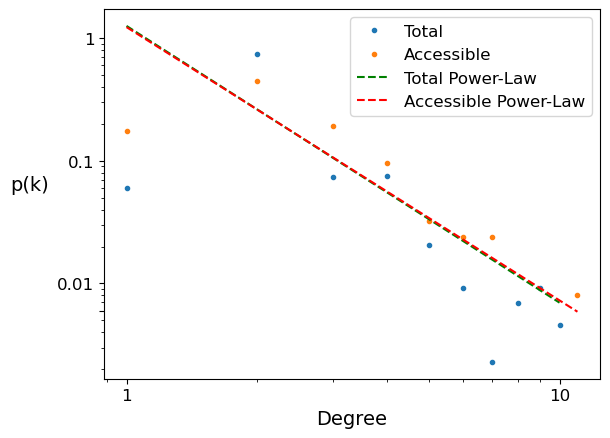

In [19]:
fig, ax = plt.subplots()

countst = Counter(d for n, d in GTot.degree())
histt = [countst.get(i, 0) for i in range(min(countst), max(countst) + 1)]
degree_sequencet = np.array(sorted([d for n, d in GTot.degree()], reverse=True))
degree_freqt = np.array(histt)/NT
degreest = range(1,len(degree_freqt)+1)
plt.loglog(degreest, degree_freqt,'.') 

countsn = Counter(d for n, d in GN.degree())
histn = [countsn.get(i, 0) for i in range(min(countsn), max(countsn) + 1)]
degree_sequencen = np.array(sorted([d for n, d in GN.degree()], reverse=True))
degree_freqn = np.array(histn)/N
degreesn =range(1,len(degree_freqn)+1)
plt.loglog(degreesn, degree_freqn,'.') 

fitt = powerlaw.Fit(degree_sequencet, xmin=1)
fitt.power_law.plot_pdf(color='g', linestyle='--')
fitn = powerlaw.Fit(degree_sequencen, xmin=1)
fitn.power_law.plot_pdf(color='r', linestyle='--')

plt.xticks([1, 10],['1','10'])
plt.yticks([.006,.01,.1,1],[' ','0.01','0.1','1'])
ax.tick_params(axis='both', which='major', labelsize=12)
ax.yaxis.labelpad=20
plt.xlabel('Degree', fontsize=14)
plt.ylabel('p(k)', rotation=0, fontsize=14)
plt.legend(["Total","Accessible","Total Power-Law", "Accessible Power-Law"],fontsize=12)
plt.savefig('Fig10.tiff', bbox_inches='tight', dpi=300)
plt.show()

In [20]:
print(fitt.power_law.alpha)
print(fitn.power_law.alpha)

2.2553012666195156
2.2270887179320384


# Income

In [22]:
import requests
import re
import geopandas as gpd
import pandas as pd
import numpy as np
from shapely.geometry import Point
import io
import zipfile
import urllib.request

In [46]:
url = "https://data.ny.gov/resource/39hk-dx4f.json?$limit=500"
response = requests.get(url)
nyc_stations = pd.DataFrame(response.json())
nyc_stations["gtfs_latitude"] = pd.to_numeric(nyc_stations["gtfs_latitude"])
nyc_stations["gtfs_longitude"] = pd.to_numeric(nyc_stations["gtfs_longitude"])

# ── 2. Load neighborhood boundaries ──────────────────────────────────────────
neighborhoods = gpd.read_file(
    "https://services5.arcgis.com/GfwWNkhOj9bNBqoJ/arcgis/rest/services/NYC_Neighborhood_Tabulation_Areas_2020/FeatureServer/0/query?where=1=1&outFields=*&outSR=4326&f=geojson"
).to_crs("EPSG:4326")

# ── 3. Name mapping ───────────────────────────────────────────────────────────
name_mapping = {
    '125th St (4)': '125 St', '125th St (A)': '125 St', '135th St (2)': '135 St',
    '14th St (1)': '14 St', '14th St (A)': '14 St', '14th St (F)': '14 St',
    '161st St - Yankee Stadium': '161 St-Yankee Stadium',
    '168th St (A)': '168 St-Washington Hts', '170th St (4)': '170 St',
    '181st St (A)': '181 St', '1st Ave': '1 Av',
    '21st St - Queensbridge': '21 St-Queensbridge',
    '231st St': '231 St', '233rd St': '233 St', '23rd St (6)': '23 St',
    '34th St - Hudson Yards': '34 St-Hudson Yards',
    '34th St - Penn Station (1)': '34 St-Penn Station',
    '34th St - Penn Station (A)': '34 St-Penn Station',
    '3rd Ave - 149th St': '3 Av-149 St',
    '42nd St - Port Authority Bus Term': '42 St-Port Authority Bus Terminal',
    '47th-50th Sts - Rockefeller Ctr': '47-50 Sts-Rockefeller Ctr',
    '51st St': '51 St', '57th St': '57 St', '59th St': '59 St',
    '59th St - Columbus Circle': '59 St-Columbus Circle',
    '62nd St': '62 St', '66th St - Lincoln Ctr': '66 St-Lincoln Center',
    '6th Ave': '6 Av', '72nd St (1)': '72 St', '72nd St (Q)': '72 St',
    '74th St - Broadway': '74 St-Broadway', '7th Ave (FB)': '7 Av',
    '86th St (Q)': '86 St', '86th St (R)': '86 St', '8th Ave': '8 Av',
    '96th St (1)': '96 St', '96th St (Q)': '96 St',
    "Atlantic Av - Barclay's Center": 'Atlantic Av-Barclays Ctr',
    'Ave H': 'Avenue H', 'Bay Pkwy (D)': 'Bay Pkwy', 'Beach 67th St': 'Beach 67 St',
    'Bedford Ave': 'Bedford Av', 'Broadway - Lafayette St': 'Broadway-Lafayette St',
    'Brooklyn Bridge - City Hall': 'Brooklyn Bridge-City Hall',
    'Brooklyn College - Flatbush Ave': 'Flatbush Av-Brooklyn College',
    'Canal St (6)': 'Canal St', 'Canarsie - Rockaway Pkwy': 'Canarsie-Rockaway Pkwy',
    'Chambers St (1)': 'Chambers St', 'Chambers St (J)': 'Chambers St',
    'Church Ave (2)': 'Church Av', 'Church Ave (F)': 'Church Av',
    'Coney Island - Stillwell Av': 'Coney Island-Stillwell Av',
    'Crown Hts - Utica Ave': 'Crown Hts-Utica Av',
    'DeKalb Ave (B)': 'DeKalb Av', 'Dyckman St (1)': 'Dyckman St',
    'E 149th St': 'E 149 St', 'E 180th St': 'E 180 St',
    'Eastern Pkwy - Bklyn Museum': 'Eastern Pkwy-Brooklyn Museum',
    'Euclid Ave': 'Euclid Av', 'Far Rockaway - Mott Ave': 'Far Rockaway-Mott Av',
    'Flushing - Main St': 'Flushing-Main St', 'Forest Hills - 71st Av': 'Forest Hills-71 Av',
    'Franklin Ave': 'Franklin Av', 'Grand Central - 42nd St': 'Grand Central-42 St',
    'Greenpoint Ave': 'Greenpoint Av', 'Gun Hill Rd (2)': 'Gun Hill Rd',
    'Gun Hill Rd (5)': 'Gun Hill Rd', 'Herald Sq - 34th St': '34 St-Herald Sq',
    'Howard Beach - JFK Airport': 'Howard Beach-JFK Airport',
    'Hunts Point Ave': 'Hunts Point Av', 'Inwood - 207th St': 'Inwood-207 St',
    'Jackson Hts - Roosevelt Av': 'Jackson Hts-Roosevelt Av',
    'Jamaica - 179th St': 'Jamaica-179 St', 'Jamaica - Van Wyck': 'Jamaica-Van Wyck',
    'Jamaica Ctr - Parsons / Archer': 'Jamaica Center-Parsons/Archer',
    'Jay St - MetroTech': 'Jay St-MetroTech', 'Kew Gardens - Union Tpke': 'Kew Gardens-Union Tpke',
    'Kings Hwy (B)': 'Kings Hwy', 'Lexington Ave - 53rd St': 'Lexington Av/53 St',
    'Lexington Ave - 63rd St': 'Lexington Av/63 St', 'Livonia Ave': 'Livonia Av',
    'Lortimer St': 'Lorimer St', 'Marcy Ave': 'Marcy Av',
    'Metropolitan Ave': 'Metropolitan Av',
    'Middle Village - Metropolitan Ave': 'Middle Village-Metropolitan Av',
    'Myrtle - Wyckoff Aves': 'Myrtle-Wyckoff Avs', 'New Utrecht Ave': 'New Utrecht Av',
    'Ozone Park - Lefferts Blvd': 'Ozone Park-Lefferts Blvd',
    'Pelham Pkwy (2)': 'Pelham Pkwy', 'Queens Plz': 'Queens Plaza',
    'Rockaway Park - Beach 116 St': 'Rockaway Park-Beach 116 St',
    'Roosevelt Island - Main St': 'Roosevelt Island',
    'Sutphin Blvd - Archer Av': 'Sutphin Blvd-Archer Av-JFK Airport',
    'Times Sq - 42nd St': 'Times Sq-42 St', 'Tremont Ave': 'Tremont Av',
    'Union Sq - 14th St': '14 St-Union Sq', 'Utica Ave': 'Utica Av',
    'W 4th St - Washington Sq': 'W 4 St-Wash Sq',
    'Westchester Sq': 'Westchester Sq-E Tremont Av', 'Woodside - 61st St': '61 St-Woodside',
}

# ── 4. Build station dataframe from accessible network nodes ──────────────────
stations_df = pd.DataFrame({"station": list(GN.nodes())})  # replace GN with your accessible NYC graph
stations_df["station_mapped"] = stations_df["station"].map(name_mapping).fillna(
    stations_df["station"].str.replace(r'\s*\(.*?\)', '', regex=True).str.strip()
)
stations_df["line_clean"] = stations_df["station"].str.extract(r'\((.*?)\)')

# ── 5. Match each node to best MTA row by name then line ─────────────────────
def best_match(row):
    matches = nyc_stations[nyc_stations["stop_name"] == row["station_mapped"]]
    if len(matches) == 0:
        return pd.Series({"gtfs_latitude": None, "gtfs_longitude": None})
    if len(matches) == 1:
        return matches.iloc[0][["gtfs_latitude", "gtfs_longitude"]]
    if pd.notna(row["line_clean"]):
        lines = set(row["line_clean"].replace(",", " ").split())
        for _, candidate in matches.iterrows():
            candidate_lines = set(str(candidate["daytime_routes"]).replace(",", " ").split())
            if lines & candidate_lines:
                return candidate[["gtfs_latitude", "gtfs_longitude"]]
    return matches.iloc[0][["gtfs_latitude", "gtfs_longitude"]]

coords = stations_df.apply(best_match, axis=1)
stations_df["latitude"] = pd.to_numeric(coords["gtfs_latitude"])
stations_df["longitude"] = pd.to_numeric(coords["gtfs_longitude"])

# ── 6. Spatial join to neighborhoods ─────────────────────────────────────────
gdf = gpd.GeoDataFrame(
    stations_df.dropna(subset=["latitude", "longitude"]),
    geometry=[Point(lon, lat) for lon, lat in zip(
        stations_df.dropna(subset=["latitude", "longitude"])["longitude"],
        stations_df.dropna(subset=["latitude", "longitude"])["latitude"])],
    crs="EPSG:4326"
)

stations_with_nta = gpd.sjoin(gdf, neighborhoods[["geometry", "NTAName"]], how="left", predicate="within")
stations_with_nta = stations_with_nta.drop_duplicates(subset="station")

In [27]:
counties = ["005", "047", "061", "081", "085"]
all_income = []

for county in counties:
    url = f"https://api.census.gov/data/2021/acs/acs5?get=NAME,B19013_001E&for=tract:*&in=state:36%20county:{county}"
    response = requests.get(url)
    data = response.json()
    df = pd.DataFrame(data[1:], columns=data[0])
    all_income.append(df)

income_df = pd.concat(all_income)
income_df["MedianIncome"] = pd.to_numeric(income_df["B19013_001E"], errors="coerce")
income_df["GEOID"] = income_df["state"] + income_df["county"] + income_df["tract"]

urllib.request.urlretrieve("https://www2.census.gov/geo/tiger/TIGER2021/TRACT/tl_2021_36_tract.zip", "tl_2021_36_tract.zip")
with zipfile.ZipFile("tl_2021_36_tract.zip", "r") as z:
    z.extractall("tl_2021_36_tract")

tracts = gpd.read_file("tl_2021_36_tract/tl_2021_36_tract.shp")
nyc_fips = ['005', '047', '061', '081', '085']
tracts = tracts[tracts['COUNTYFP'].isin(nyc_fips)].to_crs("EPSG:4326")
tracts["GEOID"] = tracts["STATEFP"] + tracts["COUNTYFP"] + tracts["TRACTCE"]
tracts = tracts.merge(income_df[["GEOID", "MedianIncome"]], on="GEOID", how="left")
print(f"Tracts loaded: {len(tracts)}")

Tracts loaded: 2327


In [45]:
# ── 1. Get Community District boundaries ─────────────────────────────────────
cd_boundaries = gpd.read_file(
    "https://services5.arcgis.com/GfwWNkhOj9bNBqoJ/arcgis/rest/services/NYC_Community_Districts/FeatureServer/0/query?where=1=1&outFields=*&outSR=4326&f=geojson"
).to_crs("EPSG:4326")

# ── 2. Aggregate tract income to Community District level ────────────────────
tracts_with_cd = gpd.sjoin(
    tracts[["geometry", "GEOID", "MedianIncome"]].dropna(subset=["MedianIncome"]),
    cd_boundaries[["geometry", "BoroCD"]],
    how="left", predicate="within"
)
cd_income = tracts_with_cd.groupby("BoroCD")["MedianIncome"].median().reset_index()
cd_income.columns = ["BoroCD", "CDMedianIncome"]

In [33]:
stations_with_cd = gpd.sjoin(gdf, cd_boundaries[["geometry", "boro_cd"]],
                              how="left", predicate="within")
stations_with_cd = stations_with_cd.drop_duplicates(subset="station")

# ── 4. Merge income onto stations ─────────────────────────────────────────────
stations_with_income = stations_with_cd.merge(cd_income, on="boro_cd", how="left")
stations_with_income["CDMedianIncome"] = stations_with_income["CDMedianIncome"].replace(-666666666, np.nan)

Missing income after cleaning: 4


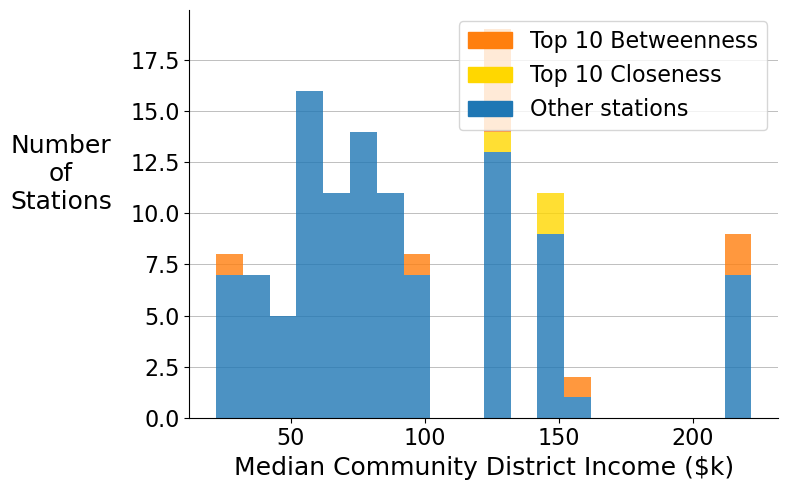

In [30]:
top10b = set([node for node, _ in sorted(Ben.items(), key=lambda x: x[1], reverse=True)[:10]])
top10c = set([node for node, _ in sorted(Cen.items(), key=lambda x: x[1], reverse=True)[:10]])

def get_color(station):
    if station in top10b:
        return "tab:orange"
    elif station in top10c:
        return "gold"
    else:
        return "tab:blue"

stations_with_income["color"] = stations_with_income["station"].apply(get_color)

income_vals = stations_with_income["CDMedianIncome"].dropna()
colors = stations_with_income.loc[stations_with_income["CDMedianIncome"].notna(), "color"]

_, bin_edges = np.histogram(income_vals, bins=20)
color_order = {"tab:blue": 0, "gold": 1, "tab:orange": 2}
plot_data = sorted(zip(income_vals, colors), key=lambda x: color_order.get(x[1], 0))

bin_bottoms = {}
fig, ax = plt.subplots(figsize=(8, 5))
ax.yaxis.grid(True, color="grey", linewidth=0.5, alpha=0.7)
ax.set_axisbelow(True)

for income, color in plot_data:
    bin_idx = np.digitize(income, bin_edges[:-1]) - 1
    bin_idx = min(bin_idx, len(bin_edges) - 2)
    bottom = bin_bottoms.get(bin_idx, 0)
    width = bin_edges[bin_idx + 1] - bin_edges[bin_idx]
    ax.bar(bin_edges[bin_idx], 1, width=width, bottom=bottom,
           color=color, alpha=0.8, edgecolor="none", align="edge")
    bin_bottoms[bin_idx] = bottom + 1

legend_handles = [
    Patch(color="tab:orange", label="Top 10 Betweenness"),
    Patch(color="gold",       label="Top 10 Closeness"),
    Patch(color="tab:blue",   label="Other stations"),
]
ax.legend(handles=legend_handles, fontsize=16)
ax.set_xlabel("Median Community District Income ($k)", fontsize=18)
ax.set_ylabel("Number\nof\nStations", fontsize=18, labelpad=50, rotation=0)
ax.tick_params(axis='both', labelsize=16)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x/1000)}"))
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("Fig11.tiff", dpi=300)
plt.show()

# Tourism

In [39]:
weekday_df = pd.read_excel(r"C:\Users\pinkp\Documents\Miktek Files\Betz Inaccesiblity Paper\New York Data\New_York_Population_Data.xlsx", sheet_name="Weekday", skiprows=1)
weekend_df = pd.read_excel(r"C:\Users\pinkp\Documents\Miktek Files\Betz Inaccesiblity Paper\New York Data\New_York_Population_Data.xlsx", sheet_name="Weekend", skiprows=1)

weekday_df.columns = ["station", "ridership"]
weekend_df.columns = ["station", "ridership"]

In [40]:
ridership_mapping = {
    '125th St (4)': '125 St (4,5,6)',
    '125th St (A)': '125 St (A,B,C,D)',
    '135th St (2)': '135 St (2,3)',
    '14th St (1)': '14 St (A,C,E)/8 Av (L)',
    '14th St (A)': '14 St (A,C,E)/8 Av (L)',
    '14th St (F)': '14 St (F,M,1,2,3)/6 Av (L)',
    '161st St - Yankee Stadium': '161 St-Yankee Stadium (B,D,4)',
    '168th St (A)': '168 St (A,C,1)',
    '170th St (4)': '170 St (4)',
    '175th St': '175 St (A)',
    '181st St (A)': '181 St (A)',
    '1st Ave': '1 Av (L)',
    '21st St - Queensbridge': '21 St-Queensbridge (F)',
    '231st St': '231 St (1)',
    '233rd St': '233 St (2,5)',
    '23rd St (6)': '23 St (6)',
    '34th St - Hudson Yards': '34 St-Hudson Yards (7)',
    '34th St - Penn Station (1)': '34 St-Penn Station (1,2,3)',
    '34th St - Penn Station (A)': '34 St-Penn Station (A,C,E)',
    '3rd Ave - 149th St': '3 Av-149 St (2,5)',
    '42nd St - Port Authority Bus Term': 'Times Sq-42 St (N,Q,R,S,W,1,2,3,7)/42 St (A,C,E)/Bryant Pk (B,D,F,M)/5 Av (7)',
    '47th-50th Sts - Rockefeller Ctr': '47-50 Sts-Rockefeller Center (B,D,F,M)',
    '51st St': 'Lexington Av-53 St (E,M)/51 St (6)',
    '57th St': '57 St (F)',
    '59th St': '59 St (N,R)',
    '59th St - Columbus Circle': '59 St-Columbus Circle (A,B,C,D,1)',
    '62nd St': 'New Utrecht Av (N)/62 St (D)',
    '66th St - Lincoln Ctr': '66 St-Lincoln Center (1)',
    '68 St-Hunter College': '68 St-Hunter College (6)',
    '6th Ave': '14 St (F,M,1,2,3)/6 Av (L)',
    '72nd St (1)': '72 St (1,2,3)',
    '72nd St (Q)': '72 St (Q)',
    '74th St - Broadway': '74-Broadway (7)/Jackson Hts-Roosevelt Av (E,F,M,R)',
    '7th Ave (FB)': '7 Av (B,Q)',
    '86th St (Q)': '86 St (Q)',
    '86th St (R)': '86 St. (R)',
    '8th Ave': '8 Av (N)',
    '96th St (1)': '96 St (1,2,3)',
    '96th St (Q)': '96 St (Q)',
    "Atlantic Av - Barclay's Center": 'Atlantic Av-Barclays Ctr (B,D,N,Q,R,2,3,4,5)',
    'Ave H': 'Avenue H (Q)',
    'Bay Pkwy (D)': 'Bay Pkwy (D)',
    'Beach 67th St': 'Beach 67 St-Arverne By The Sea (A)',
    'Bedford Ave': 'Bedford Av (L)',
    'Bleecker St': 'Broadway-Lafayette St (B,D,F,M)/Bleecker St (6)',
    'Borough Hall': 'Court St (R)/Borough Hall (2,3,4,5)',
    'Bowling Green': 'Bowling Green (4,5)',
    'Broadway - Lafayette St': 'Broadway-Lafayette St (B,D,F,M)/Bleecker St (6)',
    'Brooklyn Bridge - City Hall': 'Brooklyn Bridge-City Hall (4,5,6)/Chambers St (J,Z)',
    'Brooklyn College - Flatbush Ave': 'Flatbush Av-Brooklyn College (2,5)',
    'Canal St (6)': 'Canal St (J,N,Q,R,W,Z,6)',
    'Canarsie - Rockaway Pkwy': 'Canarsie-Rockaway Pkwy (L)',
    'Chambers St (1)': 'Chambers St (1,2,3)',
    'Chambers St (J)': 'Chambers St (A,C)/WTC (E)/Park Place (2,3)/Cortlandt (R,W)',
    'Church Ave (2)': 'Church Av (2,5)',
    'Church Ave (F)': 'Church Av (F,G)',
    'Coney Island - Stillwell Av': 'Coney Island-Stillwell Av (D,F,N,Q)',
    'Cortlandt St': 'Chambers St (A,C)/WTC (E)/Park Place (2,3)/Cortlandt (R,W)',
    'Court Sq': 'Court Sq (E,G,M,7)',
    'Crown Hts - Utica Ave': 'Crown Heights-Utica Av (3,4)',
    'DeKalb Ave (B)': 'DeKalb Av (B,Q,R)',
    'Dyckman St (1)': 'Dyckman St (1)',
    'E 149th St': 'East 149 St (6)',
    'E 180th St': 'East 180 St (2,5)',
    'Eastern Pkwy - Bklyn Museum': 'Eastern Pkwy-Brooklyn Museum (2,3)',
    'Euclid Ave': 'Euclid Av (A,C)',
    'Far Rockaway - Mott Ave': 'Far Rockaway-Mott Av (A)',
    'Flushing - Main St': 'Flushing-Main St (7)',
    'Flushing Ave': 'Flushing Av (J,M)',
    'Fordham Rd': 'Fordham Rd (4)',
    'Forest Hills - 71st Av': 'Forest Hills-71 Av (E,F,M,R)',
    'Franklin Ave': 'Franklin Av (2,3,4,5)/Botanic Garden (S)',
    'Fulton St': 'Fulton St (A,C,J,Z,2,3,4,5)',
    'Grand Central - 42nd St': 'Grand Central-42 St (S,4,5,6,7)',
    'Grand St': 'Grand St (L)',
    'Greenpoint Ave': 'Greenpoint Av (G)',
    'Gun Hill Rd (2)': 'Gun Hill Rd (2,5)',
    'Gun Hill Rd (5)': 'Gun Hill Rd (5)',
    'Herald Sq - 34th St': '34 St-Herald Sq (B,D,F,M,N,Q,R,W)',
    'Howard Beach - JFK Airport': 'Howard Beach-JFK Airport (A)',
    'Hunts Point Ave': 'Hunts Point Av (6)',
    'Inwood - 207th St': 'Inwood-207 St (A)',
    'Jackson Hts - Roosevelt Av': '74-Broadway (7)/Jackson Hts-Roosevelt Av (E,F,M,R)',
    'Jamaica - 179th St': 'Jamaica-179 St (F)',
    'Jamaica - Van Wyck': 'Jamaica-Van Wyck (E)',
    'Jamaica Ctr - Parsons / Archer': 'Jamaica Center-Parsons-Archer (E,J,Z)',
    'Jay St - MetroTech': 'Jay St-MetroTech (A,C,F,R)',
    'Junction Blvd': 'Junction Blvd (7)',
    'Kew Gardens - Union Tpke': 'Kew Gardens-Union Turnpike (E,F)',
    'Kings Hwy (B)': 'Kings Hwy (B,Q)',
    'Kingsbridge Rd': 'Kingsbridge Rd (4)',
    'Lexington Ave - 53rd St': 'Lexington Av-53 St (E,M)/51 St (6)',
    'Lexington Ave - 63rd St': 'Lexington Av-63 St (F,Q)',
    'Livonia Ave': 'Livonia Av (L)',
    'Lortimer St': 'Lorimer St (J,M)',
    'Marcy Ave': 'Marcy Av (J,M,Z)',
    'Metropolitan Ave': 'Lorimer St (L)/Metropolitan Av (G)',
    'Middle Village - Metropolitan Ave': 'Middle Village-Metropolitan Av (M)',
    'Myrtle - Wyckoff Aves': 'Myrtle-Wyckoff Avs (L,M)',
    'New Utrecht Ave': 'New Utrecht Av (N)/62 St (D)',
    'Ozone Park - Lefferts Blvd': 'Ozone Park-Lefferts Blvd (A)',
    'Park Pl': 'Chambers St (A,C)/WTC (E)/Park Place (2,3)/Cortlandt (R,W)',
    'Pelham Bay Park': 'Pelham Bay Park (6)',
    'Pelham Pkwy (2)': 'Pelham Pkwy (2,5)',
    'Prospect Park': 'Prospect Park (B,Q,S)',
    'Queens Plz': 'Queens Plaza (E,M,R)',
    'Queensboro Plaza': 'Queensboro Plaza (N,W,7)',
    'Rockaway Park - Beach 116 St': 'Rockaway Park-Beach 116 St (A,S)',
    'Roosevelt Island - Main St': 'Roosevelt Island (F)',
    'Simpson St': 'Simpson St (2,5)',
    'South Ferry': 'South Ferry (1)/Whitehall St (R,W)',
    'Sutphin Blvd - Archer Av': 'Sutphin Blvd-Archer Av-JFK Airport (E,J,Z)',
    'Times Sq - 42nd St': 'Times Sq-42 St (N,Q,R,S,W,1,2,3,7)/42 St (A,C,E)/Bryant Pk (B,D,F,M)/5 Av (7)',
    'Tremont Ave': 'Tremont Av (B,D)',
    'Union Sq - 14th St': '14 St-Union Sq (L,N,Q,R,W,4,5,6)',
    'Utica Ave': 'Utica Av (A,C)',
    'W 4th St - Washington Sq': 'West 4 St-Washington Sq (A,B,C,D,E,F,M)',
    'Westchester Sq': 'Westchester Sq-East Tremont Av (6)',
    'Woodhaven Blvd': 'Woodhaven Blvd (J,Z)',
    'Woodside - 61st St': 'Woodside-61 St (7)',
    'World Trade Center': 'Chambers St (A,C)/WTC (E)/Park Place (2,3)/Cortlandt (R,W)',
    'WTC Cortlandt': 'WTC Cortlandt (1)',
    'Aqueduct Racetrack': 'Aqueduct Racetrack (A)',
    'Astoria Blvd': 'Astoria Blvd (N,W)',
    'Bedford Park Blvd': 'Bedford Park Blvd (B,D)',
}

# Merge weekday ridership
stations_df["station_ridership"] = stations_df["station"].map(ridership_mapping).fillna(stations_df["station"])
weekday_merged = stations_df[["station", "station_ridership"]].merge(
    weekday_df, left_on="station_ridership", right_on="station", how="left"
).rename(columns={"ridership": "weekday_ridership", "station_x": "station"})

weekend_merged = stations_df[["station", "station_ridership"]].merge(
    weekend_df, left_on="station_ridership", right_on="station", how="left"
).rename(columns={"ridership": "weekend_ridership", "station_x": "station"})

print(f"Weekday matched: {weekday_merged['weekday_ridership'].notna().sum()} / {len(weekday_merged)}")
print(f"Weekend matched: {weekend_merged['weekend_ridership'].notna().sum()} / {len(weekend_merged)}")
print("Unmatched:", weekday_merged[weekday_merged['weekday_ridership'].isna()]["station"].tolist())

Weekday matched: 125 / 125
Weekend matched: 125 / 125
Unmatched: []


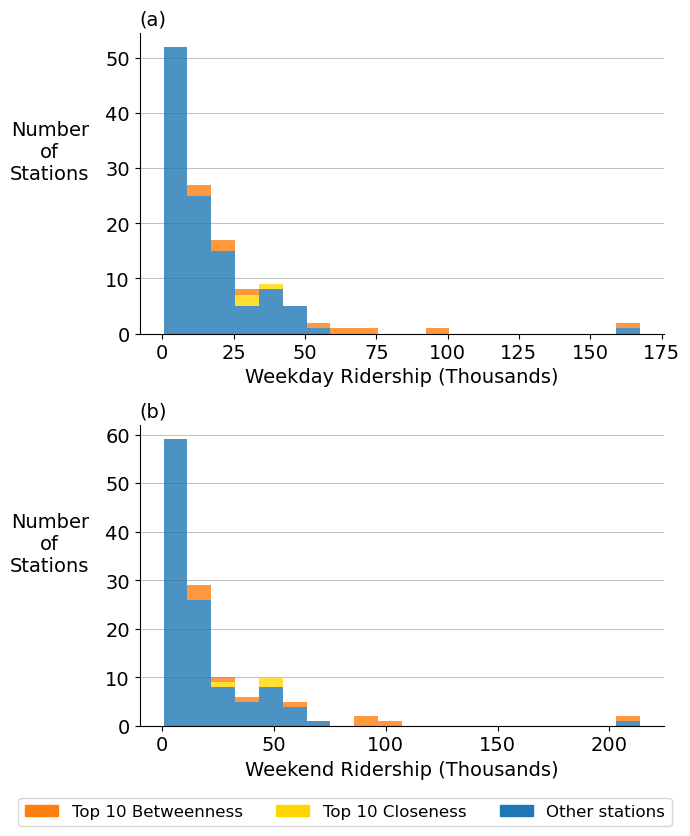

In [43]:
stations_with_ridership = weekday_merged[["station", "weekday_ridership"]].merge(
    weekend_merged[["station", "weekend_ridership"]], on="station", how="left"
)

# Add colors
stations_with_ridership["color"] = stations_with_ridership["station"].apply(get_color)

# Plot
import string
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 8))

for plot_idx, (ax, col, title) in enumerate([
    (ax1, "weekday_ridership", "Weekday Ridership"),
    (ax2, "weekend_ridership", "Weekend Ridership")
]):
    pop_vals = stations_with_ridership[col].dropna()
    colors = stations_with_ridership.loc[stations_with_ridership[col].notna(), "color"]

    _, bin_edges = np.histogram(pop_vals, bins=20)
    color_order = {"tab:blue": 0, "gold": 1, "tab:orange": 2}
    plot_data = sorted(zip(pop_vals, colors), key=lambda x: color_order.get(x[1], 0))

    bin_bottoms = {}
    ax.yaxis.grid(True, color="grey", linewidth=0.5, alpha=0.7)
    ax.set_axisbelow(True)

    for pop, color in plot_data:
        bin_idx = np.digitize(pop, bin_edges[:-1]) - 1
        bin_idx = min(bin_idx, len(bin_edges) - 2)
        bottom = bin_bottoms.get(bin_idx, 0)
        width = bin_edges[bin_idx + 1] - bin_edges[bin_idx]
        ax.bar(bin_edges[bin_idx], 1, width=width, bottom=bottom,
               color=color, alpha=0.8, edgecolor="none", align="edge")
        bin_bottoms[bin_idx] = bottom + 1

    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x/1000)}"))
    ax.set_title(f"({string.ascii_lowercase[plot_idx]})", loc="left", fontsize=14)
    ax.set_xlabel(f"{title} (Thousands)", fontsize=14)
    ax.set_ylabel("Number\nof\nStations", rotation=0, labelpad=40, fontsize=14)
    ax.tick_params(axis='both', labelsize=14)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

legend_handles = [
    Patch(color="tab:orange", label="Top 10 Betweenness"),
    Patch(color="gold",       label="Top 10 Closeness"),
    Patch(color="tab:blue",   label="Other stations"),
]
fig.legend(handles=legend_handles, fontsize=12, loc="lower center",
           ncol=3, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.savefig("Fig12.tiff", dpi=300)
plt.show()